<a href="https://colab.research.google.com/github/crystalloide/IA_102_IA_Agentique/blob/main/IA102_Atelier3_PlanExecute_vs_ReWOO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA102 — Partie 3 · Atelier : comparaison des frameworks de planification LLM-MA

## Plan-and-Execute 🆚 ReWOO, implémentés avec LangGraph

| | |
|---|---|
| **Formation** | IA102 — IA agentique : conception d'applications multi-agents basées sur des LLMs |
| **Chapitre** | 3 — Orchestration et planification multi-agents avancée |
| **Durée indicative** | 2 h 30 |
| **Livrables** | ce notebook exécuté + la synthèse `synthese_atelier3.md` générée à la fin |

### Objectifs de l'atelier
1. **Implémenter** une architecture **Plan-and-Execute** (planificateur → exécuteur → re-planificateur) capable de **s'adapter dynamiquement** à un imprévu.
2. **Implémenter** une architecture **ReWOO** (*Reasoning WithOut Observation* : planificateur → workers → solveur) qui **planifie tout à l'avance** pour économiser les appels LLM.
3. **Mesurer et comparer** les deux approches sur les mêmes scénarios : nombre d'appels LLM, tokens, durée, appels d'outils, qualité du résultat.
4. **Rédiger une synthèse** argumentée : quelle architecture pour quel besoin ?

### Le cas d'usage : un système multi-agents logistique
L'entreprise fictive **NordOuest Logistique** exploite 4 entrepôts (Bordeaux, Lille, Lyon, Marseille). Les agents doivent traiter des demandes clients en consultant le système de gestion d'entrepôt (WMS) au travers d'**outils** :

| Outil | Rôle |
|---|---|
| `consulter_stock[produit]` | stock disponible par entrepôt |
| `tarifs_transport[ville]` | coût unitaire et délai de livraison depuis chaque entrepôt |
| `reserver_stock[allocation]` | réserve du stock (action **avec effet de bord**) |
| `calculatrice[expression]` | calcul arithmétique exact |

Trois scénarios sont joués par les deux architectures :

| Scénario | Description | Ce qu'il met en évidence |
|---|---|---|
| **S1 — Devis simple** | coût et délai d'une expédition depuis Lyon | tâche prévisible, sans action |
| **S2 — Commande, environnement stable** | répartition optimale + réservation | planification multi-étapes |
| **S3 — Commande, changement dynamique** | idem, mais un **incident survient pendant l'exécution** (le quai de Lyon est bloqué au moment de réserver) | capacité d'**adaptation** |

### Déroulé
| Étape | Contenu |
|---|---|
| 0 | Installation des bibliothèques (versions figées) |
| 1 | Configuration du LLM (clé API gratuite **ou** mode simulation automatique) |
| 2 | Génération des fichiers de test |
| 3 | Les outils de l'environnement |
| 4 | Architecture **Plan-and-Execute** |
| 5 | Architecture **ReWOO** |
| 6 | Banc de comparaison et visualisation |
| 7 | Bonus : parallélisation façon **LLMCompiler** |
| 8 | Exercices (avec solutions) |
| 9 | Génération de la synthèse |

> 💡 **Exécution** : `Exécution › Tout exécuter` fonctionne sans aucune modification. Sans clé API, le notebook bascule automatiquement en **mode simulation** (LLM scripté, déterministe) : les graphes, les outils et les mesures sont réels, seules les réponses du LLM sont pré-écrites. Pour travailler avec un vrai LLM, voir l'étape 1.

---
## Étape 0 — Installation des bibliothèques

Les versions sont **figées** pour garantir un fonctionnement identique à celui validé le 22/09/2026 (Colab, Python 3.12) :

| Paquet | Version | Rôle |
|---|---|---|
| `langgraph` | 1.2.11 | orchestration des agents sous forme de graphes d'états |
| `langchain-core` | 1.6.3 | socle requis par LangGraph |
| `openai` | 2.54.0 | client universel pour les API compatibles OpenAI (Groq, Gemini, Mistral, OpenAI, Ollama…) |

> Pip peut afficher des avertissements de dépendances concernant d'autres paquets préinstallés de Colab : ils sont sans effet sur cet atelier. **Aucun redémarrage de session n'est nécessaire.**

In [1]:
%pip install -q "langgraph==1.2.11" "langgraph-checkpoint==4.2.0" "langgraph-prebuilt==1.1.0" "langgraph-sdk==0.4.4" "langchain-core==1.6.3" "openai==2.54.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 3.0 MB/s eta 0:00:00


In [2]:
import sys, platform
from importlib.metadata import version

print("Python :", platform.python_version())
for paquet in ["langgraph", "langchain-core", "openai", "pandas", "matplotlib"]:
    print(f"{paquet:<15} {version(paquet)}")

assert sys.version_info >= (3, 10), "Python 3.10 minimum est requis"
assert version("langgraph").startswith("1."), "LangGraph 1.x attendu"
print("\n✅ Environnement prêt")

Python : 3.13.15
langgraph       1.2.11
langchain-core  1.6.3
openai          2.54.0
pandas          2.2.3
matplotlib      3.10.0

✅ Environnement prêt


---
## Étape 1 — Configuration du LLM

Le notebook utilise le client `openai`, compatible avec la plupart des fournisseurs. Il **détecte automatiquement** une clé API, dans cet ordre :

1. la variable `CLE_API_MANUELLE` ci-dessous (si vous la renseignez) ;
2. les **secrets Colab** (icône 🔑 dans la barre latérale gauche, activer « Accès au notebook ») ou les variables d'environnement :

| Nom du secret | Fournisseur | Obtenir une clé gratuite |
|---|---|---|
| `GROQ_API_KEY` | Groq *(recommandé : rapide, gratuit)* | https://console.groq.com/keys |
| `GEMINI_API_KEY` ou `GOOGLE_API_KEY` | Google Gemini | https://aistudio.google.com/apikey |
| `MISTRAL_API_KEY` | Mistral AI | https://console.mistral.ai |
| `OPENAI_API_KEY` | OpenAI (payant) | https://platform.openai.com |
| `LLM_API_KEY` + `LLM_BASE_URL` | tout serveur compatible OpenAI (Ollama, vLLM, proxy du formateur…) | — |

3. **Aucune clé trouvée, ou clé invalide → mode simulation** automatique.

Le modèle est choisi **dynamiquement** parmi ceux réellement disponibles chez le fournisseur (les catalogues évoluent souvent : par exemple Groq a retiré `llama-3.3-70b-versatile` en août 2026).

> ⚠️ **Quotas gratuits** : chez Groq, le palier gratuit est limité à environ 8 000 tokens/minute et 200 000 tokens/jour par modèle. Une exécution complète du notebook consomme de l'ordre de 100 000 tokens. Le client réessaie automatiquement après une erreur 429 : certaines exécutions peuvent donc marquer une pause de quelques secondes. Si le quota est définitivement épuisé, le notebook **bascule automatiquement en simulation** et le signale. **Chaque stagiaire doit utiliser sa propre clé.**

In [3]:
# ============ PARAMÈTRES (facultatifs — le notebook fonctionne sans rien modifier) ============
MODE_LLM = "auto"            # "auto" (clé si disponible, sinon simulation) | "api" | "simulation"
CLE_API_MANUELLE = ""        # optionnel : collez ici une clé API
FOURNISSEUR_MANUEL = "groq"  # fournisseur de la clé manuelle : "groq" | "gemini" | "mistral" | "openai"
MODELE_FORCE = ""            # optionnel : forcer un modèle précis (ex. "openai/gpt-oss-120b")
# ============================================================================================

import os, re, json, time, threading
import openai
from openai import OpenAI

FOURNISSEURS = {
    "groq": {
        "base_url": "https://api.groq.com/openai/v1",
        "secrets": ["GROQ_API_KEY"],
        "preferes": ["openai/gpt-oss-120b", "qwen/qwen3.8-27b", "openai/gpt-oss-20b",
                     "llama-3.3-70b-versatile"],
    },
    "gemini": {
        "base_url": "https://generativelanguage.googleapis.com/v1beta/openai/",
        "secrets": ["GEMINI_API_KEY", "GOOGLE_API_KEY"],
        "preferes": ["gemini-2.5-flash", "gemini-flash-latest", "gemini-3-flash",
                     "gemini-2.5-flash-lite", "gemini-2.0-flash"],
    },
    "mistral": {
        "base_url": "https://api.mistral.ai/v1",
        "secrets": ["MISTRAL_API_KEY"],
        "preferes": ["mistral-small-latest", "mistral-medium-latest", "open-mistral-nemo"],
    },
    "openai": {
        "base_url": None,
        "secrets": ["OPENAI_API_KEY"],
        "preferes": ["gpt-4.1-mini", "gpt-4o-mini", "gpt-5-mini"],
    },
    "compatible": {
        "base_url": None,  # lu dans LLM_BASE_URL
        "secrets": ["LLM_API_KEY"],
        "preferes": [],
    },
}


def lire_secret(nom):
    """Lit un secret Colab, puis une variable d'environnement. Ne lève jamais d'exception."""
    try:
        from google.colab import userdata
        valeur = userdata.get(nom)
        if valeur:
            return valeur.strip()
    except Exception:
        pass
    valeur = os.environ.get(nom, "")
    return valeur.strip() or None


def detecter_fournisseur():
    if CLE_API_MANUELLE.strip():
        return FOURNISSEUR_MANUEL, CLE_API_MANUELLE.strip()
    for nom, conf in FOURNISSEURS.items():
        for secret in conf["secrets"]:
            cle = lire_secret(secret)
            if cle:
                return nom, cle
    return None, None


def choisir_modele(client, fournisseur):
    """Choisit le premier modèle préféré réellement disponible (catalogue interrogé en direct)."""
    if MODELE_FORCE:
        return MODELE_FORCE
    if fournisseur == "compatible" and lire_secret("LLM_MODEL"):
        return lire_secret("LLM_MODEL")
    preferes = FOURNISSEURS[fournisseur]["preferes"]
    try:
        disponibles = [m.id.replace("models/", "") for m in client.models.list()]
    except Exception as e:
        print(f"   (catalogue des modèles indisponible : {type(e).__name__}) → modèle par défaut")
        disponibles = []
    for m in preferes:
        if m in disponibles:
            return m
    exclus = ("whisper", "tts", "guard", "embed", "image", "audio", "live", "orpheus",
              "vision", "moderation", "transcribe", "realtime", "search", "compound")
    candidats = [m for m in disponibles if not any(x in m.lower() for x in exclus)]
    if candidats:
        return sorted(candidats)[0]
    if preferes:
        return preferes[0]
    raise RuntimeError("Aucun modèle disponible : définissez MODELE_FORCE")


class LLMApi:
    """Appel d'un LLM via l'API compatible OpenAI, tolérant aux différences entre fournisseurs."""
    simulation = False

    def __init__(self, fournisseur, cle):
        conf = FOURNISSEURS[fournisseur]
        base_url = conf["base_url"] or (lire_secret("LLM_BASE_URL") if fournisseur == "compatible" else None)
        # max_retries : réessais automatiques (erreurs 429 de quota, 5xx) avec prise en compte de retry-after
        self.client = OpenAI(api_key=cle, base_url=base_url, max_retries=8, timeout=180)
        self.fournisseur = fournisseur
        self.modele = choisir_modele(self.client, fournisseur)
        self.params_refuses = set()

    def generer(self, role, messages, json_mode=False):
        kwargs = {"model": self.modele, "messages": messages}
        if "temperature" not in self.params_refuses:
            kwargs["temperature"] = 0
        if json_mode and "response_format" not in self.params_refuses:
            kwargs["response_format"] = {"type": "json_object"}
        if "gpt-oss" in self.modele and "reasoning_effort" not in self.params_refuses:
            # plus de raisonnement pour les rôles de planification, moins pour l'exécution
            kwargs["reasoning_effort"] = EFFORT_RAISONNEMENT.get(role, "low")
        for _ in range(4):
            try:
                rep = self.client.chat.completions.create(**kwargs)
                break
            except openai.BadRequestError as e:
                msg = str(e).lower()
                retire = None
                for p in ["response_format", "reasoning_effort", "temperature"]:
                    if p in kwargs and (p in msg or (p == "response_format" and "json" in msg)):
                        retire = p
                        break
                if retire is None:
                    raise
                kwargs.pop(retire)
                self.params_refuses.add(retire)
        else:
            raise RuntimeError("Appel LLM impossible après adaptation des paramètres")
        texte = rep.choices[0].message.content or ""
        usage = getattr(rep, "usage", None)
        t_in = getattr(usage, "prompt_tokens", None) or estimer_tokens(messages)
        t_out = getattr(usage, "completion_tokens", None) or max(1, len(texte) // 4)
        return texte, t_in, t_out


EFFORT_RAISONNEMENT = {"pe_planificateur": "medium", "pe_replanificateur": "medium",
                       "rewoo_planificateur": "medium", "verificateur": "medium"}


def estimer_tokens(messages):
    return max(1, sum(len(m.get("content") or "") for m in messages) // 4)


print("Configuration LLM :")
LLM = None
if MODE_LLM != "simulation":
    fournisseur, cle = detecter_fournisseur()
    if fournisseur is None:
        print("   Aucune clé API détectée.")
        if MODE_LLM == "api":
            raise RuntimeError("MODE_LLM='api' mais aucune clé n'a été trouvée")
    else:
        try:
            LLM = LLMApi(fournisseur, cle)
            texte, _, _ = LLM.generer("test", [{"role": "user", "content": "Réponds uniquement : OK"}])
            print(f"   ✅ Fournisseur : {fournisseur} | modèle : {LLM.modele} | test : {texte.strip()[:40]!r}")
        except Exception as e:
            print(f"   ❌ Échec de connexion à {fournisseur} : {type(e).__name__} — {str(e)[:200]}")
            LLM = None
            if MODE_LLM == "api":
                raise
print("   Mode :", "API réelle" if LLM else "SIMULATION (LLM scripté — la classe LLMSimule est définie à l'étape 3)")

Configuration LLM :
   ✅ Fournisseur : groq | modèle : openai/gpt-oss-120b | test : 'OK'
   Mode : API réelle


### Suivi des appels LLM

Toutes les interactions avec le LLM passent par `appeler_llm()`, qui enregistre le **rôle** de l'agent appelant, les **tokens** consommés et la **durée**. C'est la base de la comparaison des architectures. La fonction `appeler_llm_json()` ajoute une **validation du JSON** avec une nouvelle tentative guidée en cas de réponse mal formée : un point clé de la robustesse des agents.

In [4]:
VERBOSE = True  # affiche la trace des agents


class SuiviLLM:
    def __init__(self):
        self.verrou = threading.Lock()
        self.reset()

    def reset(self):
        self.appels = []

    def enregistrer(self, role, t_in, t_out, duree):
        with self.verrou:
            self.appels.append({"role": role, "tokens_in": t_in, "tokens_out": t_out, "duree": duree})

    def resume(self):
        return {
            "appels_llm": len(self.appels),
            "tokens_in": sum(a["tokens_in"] for a in self.appels),
            "tokens_out": sum(a["tokens_out"] for a in self.appels),
            "duree_llm_s": round(sum(a["duree"] for a in self.appels), 2),
        }

    def par_role(self):
        roles = {}
        for a in self.appels:
            roles[a["role"]] = roles.get(a["role"], 0) + 1
        return roles


SUIVI = SuiviLLM()


def nettoyer(texte):
    """Retire les blocs de raisonnement <think>…</think> émis par certains modèles."""
    texte = re.sub(r"<think>.*?</think>", "", texte or "", flags=re.S)
    return texte.strip()


def afficher(prefixe, texte, limite=600):
    if VERBOSE:
        texte = str(texte)
        if len(texte) > limite:
            texte = texte[:limite] + " […]"
        print(f"{prefixe} {texte}")


ERREURS_BLOQUANTES = (openai.RateLimitError, openai.AuthenticationError, openai.PermissionDeniedError,
                      openai.APIConnectionError, openai.NotFoundError)


def appeler_llm(role, messages, json_mode=False):
    """Point d'entrée unique vers le LLM (API réelle ou simulation), avec mesure du coût."""
    global LLM
    debut = time.perf_counter()
    try:
        moteur = LLM if LLM is not None else LLM_SIMULE
        texte, t_in, t_out = moteur.generer(role, messages, json_mode=json_mode)
    except ERREURS_BLOQUANTES as e:
        if LLM is None or MODE_LLM != "auto":
            raise
        # Quota épuisé ou clé révoquée malgré les réessais : on bascule en simulation pour ne pas bloquer l'atelier
        print(f"\n⛔ API indisponible ({type(e).__name__} : {str(e)[:150]})\n"
              "   → BASCULE AUTOMATIQUE EN MODE SIMULATION pour la suite du notebook.\n")
        LLM = None
        texte, t_in, t_out = LLM_SIMULE.generer(role, messages, json_mode=json_mode)
    SUIVI.enregistrer(role, t_in, t_out, time.perf_counter() - debut)
    return nettoyer(texte)


def mode_courant():
    return f"API {LLM.fournisseur} / {LLM.modele}" if LLM is not None else "simulation"


def extraire_json(texte):
    """Extrait le premier objet JSON d'un texte (tolère ```json, texte autour, etc.)."""
    t = nettoyer(texte)
    bloc = re.search(r"```(?:json)?\s*(.*?)```", t, re.S)
    if bloc:
        t = bloc.group(1)
    debut = t.find("{")
    if debut < 0:
        raise ValueError("aucun objet JSON trouvé")
    profondeur, dans_chaine, echappe = 0, False, False
    for i in range(debut, len(t)):
        c = t[i]
        if dans_chaine:
            if echappe:
                echappe = False
            elif c == "\\":
                echappe = True
            elif c == '"':
                dans_chaine = False
        elif c == '"':
            dans_chaine = True
        elif c == "{":
            profondeur += 1
        elif c == "}":
            profondeur -= 1
            if profondeur == 0:
                return json.loads(t[debut:i + 1])
    raise ValueError("objet JSON incomplet")


def appeler_llm_json(role, messages, valider, essais=2):
    """Appelle le LLM, extrait et valide le JSON ; en cas d'erreur, redemande en expliquant le problème."""
    messages = list(messages)
    derniere_erreur = None
    for _ in range(essais + 1):
        texte = appeler_llm(role, messages, json_mode=True)
        try:
            return valider(extraire_json(texte))
        except Exception as e:
            derniere_erreur = e
            afficher("   ⚠️ JSON invalide, nouvelle tentative :", e)
            messages += [
                {"role": "assistant", "content": texte or "(réponse vide)"},
                {"role": "user", "content": f"Réponse invalide ({e}). Réponds UNIQUEMENT avec l'objet JSON demandé, sans aucun texte autour."},
            ]
    raise ValueError(f"Réponse JSON invalide après {essais + 1} tentatives : {derniere_erreur}")


print("✅ Fonctions de suivi et d'appel LLM prêtes")

✅ Fonctions de suivi et d'appel LLM prêtes


---
## Étape 2 — Génération des fichiers de test

Cette cellule crée le dossier `donnees_atelier3/` qui simule les données du système d'information logistique :

| Fichier | Contenu |
|---|---|
| `entrepots.csv` | les 4 entrepôts |
| `stocks.csv` | le stock par produit et par entrepôt (extraction nocturne du WMS) |
| `tarifs_transport.csv` | coût unitaire et délai par liaison entrepôt → ville |
| `commandes.json` | la commande client CMD-7781 |
| `evenements.json` | l'**incident** qui survient pendant l'exécution du scénario S3 |

> 🧩 Observez que `stocks.csv` indique 150 unités à Lyon : l'extraction date de 06:00, l'incident survient à 09:12. **Les données consultées pendant la planification ne reflètent pas la réalité au moment de l'action.** C'est précisément la situation où la re-planification prend tout son sens.

In [5]:
import csv
from pathlib import Path

DOSSIER = Path("donnees_atelier3")
DOSSIER.mkdir(exist_ok=True)

entrepots = [
    {"entrepot": "Bordeaux", "adresse": "ZI de Bruges, 33520 Bruges", "responsable": "C. Lemoine"},
    {"entrepot": "Lille", "adresse": "Parc de la Haute Borne, 59650 Villeneuve-d'Ascq", "responsable": "P. Delattre"},
    {"entrepot": "Lyon", "adresse": "ZAC des Gaulnes, 69330 Meyzieu", "responsable": "S. Moreau"},
    {"entrepot": "Marseille", "adresse": "ZI des Estroublans, 13127 Vitrolles", "responsable": "A. Benali"},
]
stocks = [
    ("P-204", "Capteur IoT TX-204", "Bordeaux", 80),
    ("P-204", "Capteur IoT TX-204", "Lille", 60),
    ("P-204", "Capteur IoT TX-204", "Lyon", 150),
    ("P-204", "Capteur IoT TX-204", "Marseille", 200),
    ("P-310", "Passerelle LoRa GW-310", "Bordeaux", 25),
    ("P-310", "Passerelle LoRa GW-310", "Lyon", 40),
    ("P-512", "Thermostat connecté TH-512", "Lille", 300),
    ("P-512", "Thermostat connecté TH-512", "Marseille", 120),
]
tarifs = [
    ("Bordeaux", "Nantes", 1.60, 1), ("Lille", "Nantes", 2.40, 3),
    ("Lyon", "Nantes", 2.10, 2), ("Marseille", "Nantes", 1.90, 4),
    ("Bordeaux", "Paris", 2.20, 2), ("Lille", "Paris", 1.30, 1),
    ("Lyon", "Paris", 1.70, 1), ("Marseille", "Paris", 2.50, 3),
]
commandes = [{
    "id": "CMD-7781", "client": "Atlantique Domotique", "produit": "P-204",
    "quantite": 120, "destination": "Nantes", "delai_max_jours": 3,
}]
evenements = [{
    "id": "WMS-4471", "type": "blocage_expedition", "entrepot": "Lyon",
    "horodatage": "2026-09-22T09:12:00",
    "message": "quai d'expédition bloqué (panne du convoyeur), aucune expédition possible avant le 29/09/2026",
}]

with open(DOSSIER / "entrepots.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=["entrepot", "adresse", "responsable"])
    w.writeheader()
    w.writerows(entrepots)
with open(DOSSIER / "stocks.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["produit", "designation", "entrepot", "stock"])
    w.writerows(stocks)
with open(DOSSIER / "tarifs_transport.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["origine", "destination", "cout_unitaire_eur", "delai_jours"])
    w.writerows(tarifs)
(DOSSIER / "commandes.json").write_text(json.dumps(commandes, ensure_ascii=False, indent=2), encoding="utf-8")
(DOSSIER / "evenements.json").write_text(json.dumps(evenements, ensure_ascii=False, indent=2), encoding="utf-8")

import pandas as pd
for fichier in sorted(DOSSIER.iterdir()):
    print(f"📄 {fichier.name} ({fichier.stat().st_size} octets)")
display(pd.read_csv(DOSSIER / "stocks.csv"))
display(pd.read_csv(DOSSIER / "tarifs_transport.csv"))

📄 commandes.json (170 octets)
📄 entrepots.csv (257 octets)
📄 evenements.json (246 octets)
📄 stocks.csv (358 octets)
📄 tarifs_transport.csv (219 octets)


,produit,designation,entrepot,stock
0,P-204,Capteur IoT TX-204,Bordeaux,80
1,P-204,Capteur IoT TX-204,Lille,60
2,P-204,Capteur IoT TX-204,Lyon,150
3,P-204,Capteur IoT TX-204,Marseille,200
4,P-310,Passerelle LoRa GW-310,Bordeaux,25
5,P-310,Passerelle LoRa GW-310,Lyon,40
6,P-512,Thermostat connecté TH-512,Lille,300
7,P-512,Thermostat connecté TH-512,Marseille,120


,origine,destination,cout_unitaire_eur,delai_jours
0,Bordeaux,Nantes,1.6,1
1,Lille,Nantes,2.4,3
2,Lyon,Nantes,2.1,2
3,Marseille,Nantes,1.9,4
4,Bordeaux,Paris,2.2,2
5,Lille,Paris,1.3,1
6,Lyon,Paris,1.7,1
7,Marseille,Paris,2.5,3


---
## Étape 3 — Les outils de l'environnement

La classe `EnvironnementLogistique` charge les fichiers de test et expose les outils. Points importants :

* chaque appel d'outil est **journalisé** et subit une **latence simulée** (`LATENCE_OUTIL`, comme un appel d'API métier réel) : c'est ce qui permettra de mesurer le gain de la parallélisation (étape 7) ;
* `reserver_stock` a un **effet de bord** (le stock diminue) : on ne peut pas réserver deux fois la même marchandise ;
* quand `incident_actif=True` (scénario S3), la réservation à Lyon **échoue** : l'incident n'est visible **qu'au moment de l'action**.

`executer_outil()` sert de répartiteur commun aux deux architectures ; il tolère les variantes de noms d'outils produites par les LLM.

In [6]:
import ast
import operator as op

LATENCE_OUTIL = 0.3  # secondes par appel d'outil (API métier simulée)


class EnvironnementLogistique:
    def __init__(self, dossier=DOSSIER):
        self.stocks_wms = {}
        with open(dossier / "stocks.csv", encoding="utf-8") as f:
            for ligne in csv.DictReader(f):
                self.stocks_wms[(ligne["produit"], ligne["entrepot"])] = int(ligne["stock"])
        self.tarifs = {}
        with open(dossier / "tarifs_transport.csv", encoding="utf-8") as f:
            for ligne in csv.DictReader(f):
                self.tarifs[(ligne["origine"], ligne["destination"])] = (
                    float(ligne["cout_unitaire_eur"]), int(ligne["delai_jours"]))
        self.evenements = json.loads((dossier / "evenements.json").read_text(encoding="utf-8"))
        self.entrepots = sorted({e for (_, e) in self.stocks_wms} | {o for (o, _) in self.tarifs})
        self.verrou = threading.Lock()
        self.reset(incident=False)

    def reset(self, incident=False):
        self.incident_actif = incident
        self.stock_reel = dict(self.stocks_wms)
        self.reservations = []  # (produit, entrepot, quantite)
        self.journal = []       # (outil, argument, resultat)

    def _journaliser(self, outil, argument, resultat):
        time.sleep(LATENCE_OUTIL)
        with self.verrou:
            self.journal.append((outil, argument, resultat))
        return resultat

    def _entrepot(self, texte):
        for e in self.entrepots:
            if e.lower() == texte.strip().lower():
                return e
        return None

    # ---- Outils -------------------------------------------------------------------------------
    def consulter_stock(self, argument):
        m = re.search(r"P-\d+", argument.upper())
        produit = m.group(0) if m else argument.strip()
        lignes = [(e, q) for (p, e), q in sorted(self.stocks_wms.items()) if p == produit]
        if not lignes:
            return self._journaliser("consulter_stock", argument, f"ERREUR : produit inconnu '{produit}'")
        texte = f"Stock {produit} (extraction WMS du 22/09/2026 06:00) :\n"
        texte += "\n".join(f"- {e} : {q} unités" for e, q in lignes)
        texte += f"\nTotal : {sum(q for _, q in lignes)} unités"
        return self._journaliser("consulter_stock", argument, texte)

    def tarifs_transport(self, argument):
        ville = argument.strip().strip("'\"").capitalize()
        lignes = [(o, c, d) for (o, v), (c, d) in sorted(self.tarifs.items()) if v.lower() == ville.lower()]
        if not lignes:
            return self._journaliser("tarifs_transport", argument, f"ERREUR : aucune liaison vers '{ville}'")
        texte = f"Transport vers {ville} :\n"
        texte += "\n".join(f"- depuis {o} : {c:.2f} €/unité, délai {d} jour(s)" for o, c, d in lignes)
        return self._journaliser("tarifs_transport", argument, texte)

    def reserver_stock(self, argument):
        m = re.search(r"P-\d+", argument.upper())
        produit = m.group(0) if m else "P-204"
        paires = re.findall(r"([A-Za-zÀ-ÿ\-]+)['\"]?\s*[:=]\s*(\d+)", argument)
        if not paires:  # formulation libre : « 80 unités à Bordeaux »
            paires = [(e, q) for q, e in re.findall(r"(\d+)\s*(?:unités?\s*)?(?:à|de|depuis)\s+([A-Z][a-zÀ-ÿ]+)", argument)]
        if not paires:
            return self._journaliser("reserver_stock", argument,
                                     "ERREUR : format attendu 'P-204 ; Entrepot:quantité, Entrepot:quantité'")
        lignes, total = [], 0
        with self.verrou:
            for nom, qte in paires:
                entrepot, qte = self._entrepot(nom), int(qte)
                if entrepot is None:
                    lignes.append(f"- {nom} : ÉCHEC — entrepôt inconnu")
                    continue
                incident = next((ev for ev in self.evenements if self.incident_actif
                                 and ev["type"] == "blocage_expedition" and ev["entrepot"] == entrepot), None)
                if incident:
                    lignes.append(f"- {entrepot} : ÉCHEC — incident {incident['id']} : {incident['message']}")
                elif self.stock_reel.get((produit, entrepot), 0) < qte:
                    lignes.append(f"- {entrepot} : ÉCHEC — stock insuffisant "
                                  f"({self.stock_reel.get((produit, entrepot), 0)} disponibles)")
                else:
                    self.stock_reel[(produit, entrepot)] -= qte
                    self.reservations.append((produit, entrepot, qte))
                    total += qte
                    lignes.append(f"- {entrepot} : {qte} unités RÉSERVÉES (réf. RES-{len(self.reservations):04d})")
            cumul = sum(q for p, _, q in self.reservations if p == produit)
        texte = f"Réservation {produit} :\n" + "\n".join(lignes)
        texte += f"\nRéservé lors de cet appel : {total} unités — total réservé à ce jour : {cumul} unités"
        return self._journaliser("reserver_stock", argument, texte)

    def calculatrice(self, argument):
        expr = argument.replace("×", "*").replace("€", "").replace("'", "").replace('"', "")
        expr = re.sub(r"(?<=\d)\s*[xX]\s*(?=\d)", "*", expr)
        expr = re.sub(r"(\d),(\d)", r"\1.\2", expr)
        try:
            valeur = _evaluer(ast.parse(expr.strip(), mode="eval").body)
            resultat = f"{expr.strip()} = {valeur:.2f}"
        except Exception as e:
            resultat = f"ERREUR de calcul sur '{argument}' : {type(e).__name__}"
        return self._journaliser("calculatrice", argument, resultat)


_OPERATEURS = {ast.Add: op.add, ast.Sub: op.sub, ast.Mult: op.mul, ast.Div: op.truediv, ast.USub: op.neg}


def _evaluer(noeud):
    if isinstance(noeud, ast.Constant) and isinstance(noeud.value, (int, float)):
        return noeud.value
    if isinstance(noeud, ast.BinOp) and type(noeud.op) in _OPERATEURS:
        return _OPERATEURS[type(noeud.op)](_evaluer(noeud.left), _evaluer(noeud.right))
    if isinstance(noeud, ast.UnaryOp) and type(noeud.op) in _OPERATEURS:
        return _OPERATEURS[type(noeud.op)](_evaluer(noeud.operand))
    raise ValueError("expression non autorisée")


env = EnvironnementLogistique()

DESCRIPTION_OUTILS = """- consulter_stock : stock disponible d'un produit dans chaque entrepôt. Argument : la référence produit, ex. "P-204".
- tarifs_transport : coût unitaire (€/unité) et délai de livraison (jours) depuis chaque entrepôt vers une ville. Argument : la ville, ex. "Nantes".
- reserver_stock : réserve du stock (ACTION DÉFINITIVE). Argument : "P-204 ; Entrepot:quantité, Entrepot:quantité", ex. "P-204 ; Bordeaux:50, Lille:20".
- calculatrice : calcule une expression arithmétique. Argument : l'expression, ex. "50*1.60 + 20*2.40"."""

ALIAS_OUTILS = {
    "stock": "consulter_stock", "consulter_stocks": "consulter_stock",
    "tarifs": "tarifs_transport", "tarif_transport": "tarifs_transport", "transport": "tarifs_transport",
    "réserver_stock": "reserver_stock", "reservation": "reserver_stock", "reserver": "reserver_stock",
    "calculator": "calculatrice", "calcul": "calculatrice", "calculer": "calculatrice",
    "none": "aucun", "raisonnement": "aucun", "": "aucun", "null": "aucun",
}


def executer_outil(nom, argument, autoriser_llm=False):
    """Répartiteur commun : exécute un outil par son nom, sans jamais lever d'exception."""
    nom = str(nom or "").strip().strip("[]`'\"").lower()
    nom = ALIAS_OUTILS.get(nom, nom)
    argument = str(argument if argument is not None else "").strip()
    if nom == "aucun":
        return argument or "(raisonnement vide)"
    if nom == "llm" and autoriser_llm:
        return appeler_llm("rewoo_worker_llm", [
            {"role": "system", "content": "Tu es un assistant d'analyse précis. Réponds de façon concise et exacte. "
                                          "Si l'instruction impose un format de réponse, respecte-le EXACTEMENT, sans aucun texte supplémentaire."},
            {"role": "user", "content": argument},
        ])
    outils = {"consulter_stock": env.consulter_stock, "tarifs_transport": env.tarifs_transport,
              "reserver_stock": env.reserver_stock, "calculatrice": env.calculatrice}
    if nom not in outils:
        return f"ERREUR : outil inconnu '{nom}'. Outils valides : {', '.join(outils)}"
    try:
        return outils[nom](argument)
    except Exception as e:
        return f"ERREUR lors de l'exécution de {nom} : {type(e).__name__} — {e}"


# Démonstration des outils (état réinitialisé ensuite)
env.reset(incident=True)
print(executer_outil("consulter_stock", "P-204"), "\n")
print(executer_outil("tarifs_transport", "Nantes"), "\n")
print(executer_outil("reserver_stock", "P-204 ; Bordeaux:10, Lyon:10"), "\n")
print(executer_outil("calculatrice", "10*1.60 + 10*2,10"))
env.reset()

Stock P-204 (extraction WMS du 22/09/2026 06:00) :
- Bordeaux : 80 unités
- Lille : 60 unités
- Lyon : 150 unités
- Marseille : 200 unités
Total : 490 unités 

Transport vers Nantes :
- depuis Bordeaux : 1.60 €/unité, délai 1 jour(s)
- depuis Lille : 2.40 €/unité, délai 3 jour(s)
- depuis Lyon : 2.10 €/unité, délai 2 jour(s)
- depuis Marseille : 1.90 €/unité, délai 4 jour(s) 

Réservation P-204 :
- Bordeaux : 10 unités RÉSERVÉES (réf. RES-0001)
- Lyon : ÉCHEC — incident WMS-4471 : quai d'expédition bloqué (panne du convoyeur), aucune expédition possible avant le 29/09/2026
Réservé lors de cet appel : 10 unités — total réservé à ce jour : 10 unités 

10*1.60 + 10*2.10 = 37.00


### Le mode simulation (LLM scripté)

Si aucune clé API n'est disponible, `appeler_llm()` utilise la classe `LLMSimule` ci-dessous. Elle **lit réellement les prompts** construits par les agents (étape à exécuter, résultats d'outils, échecs…) et renvoie des réponses plausibles au format attendu, comme le ferait un bon LLM, afin que les graphes LangGraph, les outils et les mesures fonctionnent **exactement comme en mode API**. Le nombre de tokens est estimé (≈ 4 caractères par token) et une latence proportionnelle est simulée.

> Vous n'avez pas besoin de lire ce code en détail : c'est un « doublure » de LLM, pas un élément des architectures étudiées.

In [7]:
class LLMSimule:
    simulation = True
    modele = "simulation-deterministe"
    fournisseur = "simulation"

    def generer(self, role, messages, json_mode=False):
        prompt = "\n".join(m.get("content") or "" for m in messages)
        dernier = messages[-1].get("content") or ""
        if dernier.startswith("CONTRÔLE") and len(messages) >= 3:  # message de contrôle : on relit la demande initiale
            dernier = messages[-3].get("content") or ""
        methode = getattr(self, "_" + role, None)
        texte = methode(prompt, dernier) if methode else "OK"
        if not isinstance(texte, str):
            texte = json.dumps(texte, ensure_ascii=False)
        t_in, t_out = estimer_tokens(messages), max(1, len(texte) // 4)
        time.sleep(0.15 + t_out / 1500)  # latence simulée d'un LLM
        return texte, t_in, t_out

    # ---- outils d'analyse des prompts ----
    @staticmethod
    def _est_commande(p):
        return "CMD-" in p

    @staticmethod
    def _reservees(p):
        return {e: int(q) for e, q in re.findall(r"- ([A-Za-zÀ-ÿ]+) : (\d+) unités RÉSERVÉES", p)}

    @staticmethod
    def _tarifs(p):
        return {e: float(c) for e, c in re.findall(r"depuis ([A-Za-zÀ-ÿ]+) : ([\d.]+) €/unité", p)}

    def _repartition(self, p):
        """Répartition « raisonnée » : moins cher d'abord, délai <= 3 j, entrepôts en échec exclus."""
        stocks = {e: int(q) for e, q in re.findall(r"- ([A-Za-zÀ-ÿ]+) : (\d+) unités\n", p + "\n")}
        stocks = stocks or {"Bordeaux": 80, "Lille": 60, "Lyon": 150, "Marseille": 200}
        delais = {e: int(d) for e, d in re.findall(r"depuis ([A-Za-zÀ-ÿ]+) : [\d.]+ €/unité, délai (\d+)", p)}
        tarifs = self._tarifs(p) or {"Bordeaux": 1.6, "Lille": 2.4, "Lyon": 2.1, "Marseille": 1.9}
        delais = delais or {"Bordeaux": 1, "Lille": 3, "Lyon": 2, "Marseille": 4}
        exclus = set(re.findall(r"- ([A-Za-zÀ-ÿ]+) : ÉCHEC", p))
        deja = self._reservees(p)
        reste, repartition = 120 - sum(deja.values()), []
        for e in sorted(tarifs, key=tarifs.get):
            if reste <= 0:
                break
            if e in exclus or delais.get(e, 99) > 3:
                continue
            q = min(reste, stocks.get(e, 0) - deja.get(e, 0))
            if q > 0:
                repartition.append((e, q))
                reste -= q
        return ", ".join(f"{e}:{q}" for e, q in repartition)

    def _calcul_cout(self, p):
        tarifs, res = self._tarifs(p), self._reservees(p)
        if not res:
            return "0"
        return " + ".join(f"{q}*{tarifs.get(e, 0):.2f}" for e, q in res.items())

    # ---- Plan-and-Execute ----
    def _pe_planificateur(self, p, dernier):
        if self._est_commande(p):
            return {"etapes": [
                "Consulter le stock du produit P-204 dans tous les entrepôts",
                "Consulter les tarifs et délais de transport vers Nantes",
                "Déterminer la répartition de 120 unités qui minimise le coût de transport avec un délai de 3 jours maximum",
                "Réserver le stock selon la répartition retenue",
                "Calculer le coût total de transport des unités réservées"]}
        return {"etapes": [
            "Consulter le stock du produit P-204 pour vérifier la disponibilité à Lyon",
            "Consulter les tarifs et délais de transport vers Nantes",
            "Calculer le coût de transport de 120 unités depuis Lyon"]}

    def _pe_executeur(self, p, dernier):
        m = re.search(r"ÉTAPE À EXÉCUTER\s*:\s*(.+)", dernier)
        etape = (m.group(1) if m else dernier).lower()
        verbe = etape.split()[0] if etape.split() else ""
        if verbe.startswith("calcul"):
            if self._est_commande(p):
                return {"outil": "calculatrice", "argument": self._calcul_cout(p)}
            return {"outil": "calculatrice", "argument": f"120*{self._tarifs(p).get('Lyon', 2.10):.2f}"}
        if verbe.startswith("réserv"):
            paires = re.findall(r"([A-Z][a-zÀ-ÿ]+)\s*:\s*(\d+)", m.group(1) if m else "")
            alloc = ", ".join(f"{e}:{q}" for e, q in paires) or self._repartition(p)
            return {"outil": "reserver_stock", "argument": f"P-204 ; {alloc}"}
        if verbe.startswith("consult") and "stock" in etape:
            return {"outil": "consulter_stock", "argument": "P-204"}
        if verbe.startswith("consult") and "tarif" in etape:
            return {"outil": "tarifs_transport", "argument": "Nantes"}
        if "répartition" in etape:
            return {"outil": "aucun", "argument": f"Répartition retenue : {self._repartition(p)} "
                                                 "(Marseille exclu : délai de 4 jours > 3 jours)"}
        return {"outil": "aucun", "argument": "Étape sans action nécessaire."}

    def _pe_replanificateur(self, p, dernier):
        restantes = re.findall(r"^- (.+)$", dernier.split("ÉTAPES RESTANTES DU PLAN")[-1], re.M)
        resultats = dernier.split("ÉTAPES RESTANTES DU PLAN")[0]
        derniere = resultats.strip().split("\n→ ")[-1] if "\n→ " in resultats else ""
        if "FORCER_REPONSE" in dernier:
            restantes = []
        elif "ÉCHEC" in derniere or ("ÉCHEC" in resultats and self._est_commande(p)
                                     and sum(self._reservees(resultats).values()) < 120):
            alloc = self._repartition(resultats)
            return {"action": "continuer", "etapes": [
                f"Réserver le complément auprès d'un autre entrepôt respectant le délai ({alloc})",
                "Calculer le coût total de transport de toutes les unités réservées"]}
        if restantes:
            return {"action": "continuer", "etapes": restantes}
        calculs = re.findall(r"= ([\d.]+)", resultats)
        cout = calculs[-1] if calculs else "?"
        if self._est_commande(p):
            res = self._reservees(p)
            detail = " et ".join(f"{q} unités à {e}" for e, q in res.items())
            texte = (f"Commande CMD-7781 traitée : {sum(res.values())} unités de P-204 réservées ({detail}). "
                     f"Coût total de transport vers Nantes : {cout} €, délai respecté (3 jours maximum).")
            if "ÉCHEC" in resultats:
                texte += " L'entrepôt de Lyon, bloqué par l'incident WMS-4471, a été remplacé."
            return {"action": "repondre", "reponse": texte}
        return {"action": "repondre", "reponse": f"Le stock de Lyon (150 unités) couvre la demande. Coût de transport "
                                                f"Lyon → Nantes pour 120 unités : {cout} €, délai de livraison : 2 jours."}

    # ---- ReWOO ----
    def _rewoo_planificateur(self, p, dernier):
        if "RÉSULTATS DÉJÀ OBTENUS" in dernier:  # re-planification (exercice 3)
            alloc = self._repartition(p)
            return ("Plan: Réserver le complément auprès d'un entrepôt disponible respectant le délai.\n"
                    f"#E1 = reserver_stock[P-204 ; {alloc}]\n"
                    "Plan: Calculer le coût total des unités réservées.\n"
                    "#E2 = LLM[Tarifs : " + " ".join(dict.fromkeys(re.findall(r"- depuis [^\n]+", p)))
                    + " Réservations précédentes : " + " ".join(dict.fromkeys(re.findall(r"- \w+ : \d+ unités RÉSERVÉES", p)))
                    + " Nouvelle réservation : #E1. Calcule le coût total de transport de toutes les unités réservées.]")
        if self._est_commande(p):
            return ("Plan: Consulter le stock de P-204 dans tous les entrepôts.\n#E1 = consulter_stock[P-204]\n"
                    "Plan: Consulter les tarifs et délais vers Nantes.\n#E2 = tarifs_transport[Nantes]\n"
                    "Plan: Déterminer la répartition optimale respectant le délai.\n"
                    "#E3 = LLM[Stocks : #E1. Tarifs : #E2. Détermine la répartition de 120 unités qui minimise le coût "
                    "de transport avec un délai de 3 jours maximum. Réponds uniquement au format Entrepot:quantité, "
                    "Entrepot:quantité]\n"
                    "Plan: Réserver le stock.\n#E4 = reserver_stock[P-204 ; #E3]\n"
                    "Plan: Calculer le coût total des unités effectivement réservées.\n"
                    "#E5 = LLM[Tarifs : #E2. Réservation : #E4. Calcule le coût total de transport des unités "
                    "effectivement réservées.]")
        return ("Plan: Vérifier le stock de P-204 à Lyon.\n#E1 = consulter_stock[P-204]\n"
                "Plan: Obtenir le tarif et le délai Lyon → Nantes.\n#E2 = tarifs_transport[Nantes]\n"
                "Plan: Calculer le coût pour 120 unités.\n"
                "#E3 = LLM[À partir de #E2, calcule le coût de transport de 120 unités depuis Lyon et donne le délai.]")

    def _rewoo_worker_llm(self, p, dernier):
        if "répartition" in dernier.lower():
            return self._repartition(dernier)
        res, tarifs = self._reservees(dernier), self._tarifs(dernier)
        if res:
            total = sum(q * tarifs.get(e, 0) for e, q in res.items())
            detail = " + ".join(f"{q} × {tarifs.get(e, 0):.2f}" for e, q in res.items())
            return f"Coût des unités réservées ({sum(res.values())} unités) : {detail} = {total:.2f} €"
        if "Lyon" in dernier and tarifs:
            return f"120 × {tarifs.get('Lyon', 0):.2f} = {120 * tarifs.get('Lyon', 0):.2f} € ; délai : 2 jours"
        return "Aucune donnée exploitable."

    def _rewoo_solveur(self, p, dernier):
        preuves = dernier.split("PLAN ET PREUVES")[-1]
        res, tarifs = self._reservees(dernier), self._tarifs(dernier)
        cout = sum(q * tarifs.get(e, 0) for e, q in res.items())
        couts = re.findall(r"= ([\d.]+) €", dernier)
        detail = ", ".join(f"{q} à {e}" for e, q in res.items())
        if self._est_commande(dernier):
            if "ÉCHEC" in preuves and sum(res.values()) < 120:
                return (f"Commande CMD-7781 NON entièrement honorée : seules {sum(res.values())} unités sont réservées "
                        f"({detail}) pour un coût de {cout:.2f} €. Une réservation a échoué (incident WMS). "
                        f"Il manque {120 - sum(res.values())} unités : une nouvelle planification est nécessaire.")
            return (f"Commande CMD-7781 traitée : {sum(res.values())} unités réservées ({detail}). "
                    f"Coût total de transport : {cout:.2f} €, délai respecté.")
        return (f"Le stock de Lyon (150 unités) est suffisant. Coût de transport de 120 unités Lyon → Nantes : "
                f"{couts[-1] if couts else '?'} €, délai 2 jours.")

    def _verificateur(self, p, dernier):
        reponse = dernier.split("RÉPONSE DU SOLVEUR")[-1]
        ok = "NON entièrement" not in reponse and "manque" not in reponse.lower()
        return {"objectif_atteint": ok, "manque": "" if ok else "Il manque des unités à réserver."}


LLM_SIMULE = LLMSimule()
if LLM is None:
    print("🧪 Mode SIMULATION actif (aucune clé API) — toutes les autres briques sont réelles.")
else:
    print(f"🌐 Mode API actif : {LLM.fournisseur} / {LLM.modele}")

🌐 Mode API actif : groq / openai/gpt-oss-120b


### Scénarios et évaluation automatique

Chaque exécution est évaluée **à partir de l'état réel de l'environnement** (réservations effectivement enregistrées), et non en se fiant au texte produit par le LLM. C'est une bonne pratique d'évaluation des agents : le discours d'un agent peut être faux alors que ses actions sont justes, et inversement.

L'optimum de chaque scénario est **calculé** à partir des fichiers de test (algorithme glouton : le moins cher d'abord parmi les entrepôts respectant le délai et non bloqués).

In [8]:
COMMANDE = json.loads((DOSSIER / "commandes.json").read_text(encoding="utf-8"))[0]

SCENARIOS = {
    "S1": {"nom": "S1 — Devis simple", "incident": False, "type": "devis",
           "tache": "Devis : quel serait le coût de transport et le délai pour expédier 120 unités du produit P-204 "
                    "depuis l'entrepôt de Lyon vers Nantes ? Vérifie d'abord que le stock de Lyon est suffisant."},
    "S2": {"nom": "S2 — Commande (stable)", "incident": False, "type": "commande"},
    "S3": {"nom": "S3 — Commande (imprévu)", "incident": True, "type": "commande"},
}
TACHE_COMMANDE = (f"Traite la commande {COMMANDE['id']} du client {COMMANDE['client']} : {COMMANDE['quantite']} unités "
                  f"du produit {COMMANDE['produit']} à livrer à {COMMANDE['destination']} en {COMMANDE['delai_max_jours']} "
                  "jours maximum. Choisis la répartition entre entrepôts qui minimise le coût de transport tout en "
                  "respectant le délai, réserve le stock correspondant, puis indique le coût total de transport.")
SCENARIOS["S2"]["tache"] = SCENARIOS["S3"]["tache"] = TACHE_COMMANDE


def optimum(incident):
    """Coût minimal théorique (glouton) pour la commande, en tenant compte de l'incident éventuel."""
    bloques = {ev["entrepot"] for ev in env.evenements if incident and ev["type"] == "blocage_expedition"}
    options = sorted((c, e) for (e, v), (c, d) in env.tarifs.items()
                     if v == COMMANDE["destination"] and d <= COMMANDE["delai_max_jours"] and e not in bloques)
    reste, cout = COMMANDE["quantite"], 0.0
    for c, e in options:
        q = min(reste, env.stocks_wms.get((COMMANDE["produit"], e), 0))
        cout, reste = cout + q * c, reste - q
    return round(cout, 2)


def evaluer(scenario_id, reponse):
    sc = SCENARIOS[scenario_id]
    if sc["type"] == "devis":
        attendu = COMMANDE["quantite"] * env.tarifs[("Lyon", "Nantes")][0]
        ok = re.search(rf"{int(attendu)}(?:[.,]0+)?(?!\d)", reponse or "") is not None
        return {"statut": "✅ correct" if ok else "❌ incorrect", "succes": ok, "unites": None,
                "cout_reel": None, "cout_optimal": round(attendu, 2)}
    reserve = sum(q for p, _, q in env.reservations if p == COMMANDE["produit"])
    cout = round(sum(q * env.tarifs[(e, COMMANDE["destination"])][0] for p, e, q in env.reservations), 2)
    delai_ok = all(env.tarifs[(e, COMMANDE["destination"])][1] <= COMMANDE["delai_max_jours"] for _, e, _ in env.reservations)
    opt = optimum(sc["incident"])
    if reserve == COMMANDE["quantite"] and delai_ok and abs(cout - opt) < 0.01:
        statut, ok = "✅ optimal", True
    elif reserve == COMMANDE["quantite"] and delai_ok:
        statut, ok = "⚠️ sous-optimal", True
    elif reserve > COMMANDE["quantite"]:
        statut, ok = "❌ sur-réservation", False
    elif not delai_ok:
        statut, ok = "❌ délai non respecté", False
    else:
        statut, ok = f"❌ incomplet ({reserve}/{COMMANDE['quantite']})", False
    return {"statut": statut, "succes": ok, "unites": reserve, "cout_reel": cout, "cout_optimal": opt}


def mesurer(nom_archi, fonction, scenario_id, repetition=1):
    """Exécute une architecture sur un scénario (environnement réinitialisé) et renvoie toutes les mesures.
    Ne lève jamais d'exception : une erreur est consignée dans la ligne de résultat."""
    sc = SCENARIOS[scenario_id]
    env.reset(incident=sc["incident"])
    SUIVI.reset()
    mode_debut = mode_courant()
    debut = time.perf_counter()
    try:
        reponse, infos = fonction(sc["tache"])
        erreur = ""
    except Exception as e:
        reponse, infos, erreur = "", {"etapes_executees": None, "replanifications": None}, f"{type(e).__name__}: {e}"
        print(f"💥 Erreur pendant l'exécution : {erreur[:300]}")
    duree = time.perf_counter() - debut
    resume = SUIVI.resume()
    ligne = {"architecture": nom_archi, "scenario": sc["nom"], "repetition": repetition,
             "mode": mode_debut if mode_debut == mode_courant() else "mixte (bascule en simulation)",
             **resume, "tokens_total": resume["tokens_in"] + resume["tokens_out"],
             "duree_s": round(duree, 2), "appels_outils": len(env.journal), **infos,
             **evaluer(scenario_id, reponse), "reponse": reponse, "erreur": erreur,
             "roles": SUIVI.par_role()}
    if erreur:
        ligne["statut"], ligne["succes"] = "💥 erreur", False
    return ligne


def bilan(ligne):
    print(f"\n📊 Évaluation : {ligne['statut']} | unités réservées : {ligne['unites']} | coût réel : {ligne['cout_reel']} € "
          f"| optimum : {ligne['cout_optimal']} €")
    print(f"📊 Coût : {ligne['appels_llm']} appels LLM {ligne['roles']} | {ligne['tokens_total']} tokens "
          f"| {ligne['appels_outils']} appels d'outils | {ligne['duree_s']} s | re-planifications : {ligne['replanifications']}")


for sid, sc in SCENARIOS.items():
    print(f"{sc['nom']:<28} incident={sc['incident']!s:<5} optimum = "
          f"{optimum(sc['incident']) if sc['type'] == 'commande' else 120 * 2.10:.2f} €")

S1 — Devis simple            incident=False optimum = 252.00 €
S2 — Commande (stable)       incident=False optimum = 212.00 €
S3 — Commande (imprévu)      incident=True  optimum = 224.00 €


---
## Étape 4 — Architecture **Plan-and-Execute**

### Principe
Le paradigme **Plan-and-Execute** sépare la **stratégie** (planifier) de l'**exécution** (agir) :

```
            ┌──────────────┐
  tâche ──▶ │ PLANIFICATEUR │  (1 appel LLM : plan complet en N étapes)
            └──────┬───────┘
                   ▼
            ┌──────────────┐     outil
            │  EXÉCUTEUR    │ ─────────▶  consulter_stock, reserver_stock, …
            └──────┬───────┘  (1 appel LLM par étape)
                   ▼
            ┌──────────────────┐  plan modifié
            │ RE-PLANIFICATEUR │ ───────────────▶ retour à l'exécuteur
            └──────┬───────────┘  (1 appel LLM par étape)
                   ▼ objectif atteint
               réponse finale
```

* **Planificateur** : un LLM rédige un plan d'étapes (prompt de planification, sortie JSON).
* **Exécuteur** : pour **chaque étape**, un LLM choisit un outil et son argument (agent ReAct simplifié à une action par étape), puis l'outil est exécuté.
* **Re-planificateur** : après **chaque étape**, un LLM examine les résultats. Il peut **modifier le plan restant** (gestion des imprévus) ou **répondre**.

➡️ Coût attendu ≈ `1 + 2 × (nombre d'étapes exécutées)` appels LLM : c'est le prix de l'adaptabilité.

### 4.1 — Les prompts des trois agents

In [9]:
PROMPT_PLANIFICATEUR = f"""Tu es le PLANIFICATEUR d'un système multi-agents logistique.
Décompose l'objectif en un plan court et ordonné (3 à 6 étapes). Chaque étape doit être réalisable par un exécuteur
en UN SEUL appel à l'un des outils ci-dessous, ou par un simple raisonnement sur les résultats précédents.

Outils de l'exécuteur :
{DESCRIPTION_OUTILS}

Règles :
- Ne suppose aucune donnée : les stocks et les tarifs doivent être consultés avec les outils.
- Les étapes doivent être autonomes et précises (références produit, villes, quantités).
- N'ajoute pas d'étape « rédiger la réponse finale ».
Réponds UNIQUEMENT avec un objet JSON : {{"etapes": ["étape 1", "étape 2", "..."]}}"""

PROMPT_EXECUTEUR = f"""Tu es l'EXÉCUTEUR d'un système multi-agents logistique. Tu réalises UNE SEULE étape d'un plan.
Choisis UN outil et son argument, en t'appuyant sur les résultats des étapes précédentes.

Outils :
{DESCRIPTION_OUTILS}
- aucun : si l'étape ne demande qu'un raisonnement (choix, comparaison, synthèse) ; mets alors ta conclusion
  complète et chiffrée dans "argument".

Réponds UNIQUEMENT avec un objet JSON : {{"outil": "nom_de_l_outil", "argument": "argument de l'outil"}}"""

PROMPT_REPLANIFICATEUR = """Tu es le RE-PLANIFICATEUR d'un système multi-agents Plan-and-Execute.
Tu reçois l'objectif, les étapes déjà exécutées avec leurs résultats, et les étapes restantes du plan.

Procédure à suivre :
1. Analyse le résultat de la DERNIÈRE étape exécutée.
2. Vérifie si l'objectif est ENTIÈREMENT atteint : toutes les actions demandées ont réussi (par exemple, la TOTALITÉ
   de la quantité demandée est réservée) et toutes les informations demandées sont connues.
3. Si une étape a échoué (« ÉCHEC » ou « ERREUR »), l'objectif n'est PAS atteint. Cherche dans les résultats déjà
   obtenus une ALTERNATIVE qui respecte TOUTES les contraintes (autre entrepôt disposant du stock, délai respecté,
   coût minimal parmi les options restantes) et ajoute les étapes nécessaires. Une ressource en échec ne doit plus
   être utilisée. Un échec partiel se complète : ce qui a été réservé avec succès reste acquis.
4. Ne conclus à l'impossibilité que si AUCUNE alternative n'existe dans les données obtenues.

Réponds UNIQUEMENT avec un objet JSON de la forme :
{"analyse": "2 à 4 phrases : ce qui est fait, ce qui manque, l'alternative retenue",
 "objectif_atteint": true ou false,
 "action": "continuer" ou "repondre",
 "etapes": ["étapes restant à exécuter, si action = continuer"],
 "reponse": "réponse finale complète en français avec les chiffres clés (quantités, coûts, délais), si action = repondre"}

Règles : ne répète jamais une étape qui a réussi ; ne réserve jamais à nouveau du stock déjà réservé ;
n'annonce pas un résultat qui n'apparaît pas dans les résultats des étapes."""

CONTROLE_ECHEC = """CONTRÔLE : une étape précédente a échoué (ÉCHEC/ERREUR) et le plan n'a pas été adapté.
Avant de conclure, vérifie dans les résultats déjà obtenus s'il existe une alternative respectant toutes les
contraintes de l'objectif (autre entrepôt avec du stock disponible et un délai compatible).
- Si oui : réponds avec action = "continuer" et les étapes de remplacement.
- Sinon seulement : confirme action = "repondre" en expliquant pourquoi aucune alternative n'existe.
Réponds UNIQUEMENT avec l'objet JSON."""

print("✅ Prompts Plan-and-Execute définis")

✅ Prompts Plan-and-Execute définis


### 4.2 — Le graphe LangGraph

L'**état** du graphe (`EtatPlanExecute`) contient l'objectif, le **plan restant**, l'historique des étapes (accumulé grâce au réducteur `operator.add`) et la réponse finale. Les nœuds renvoient uniquement les clés qu'ils modifient.

**Deux choix de conception à discuter :**
* **Effort de raisonnement par rôle** (`EFFORT_RAISONNEMENT`, modèles gpt-oss) : `medium` pour le planificateur et le re-planificateur, `low` pour l'exécuteur. Planifier et re-planifier demandent plus de réflexion que choisir un outil.
* **Garde-fou de contrôle** : on a constaté en conditions réelles qu'un LLM réglé pour raisonner peu a tendance à *constater* un échec (« Lyon indisponible, 80 unités réservées ») et à conclure, au lieu de le *contourner*. Si le re-planificateur veut répondre alors qu'un échec survenu depuis la dernière re-planification n'a pas été pris en compte, on lui renvoie un message de contrôle (2 fois au plus) qui l'oblige à chercher une alternative. C'est une première forme d'**auto-critique** (voir le chapitre 4, architectures réflexives). Le contrôle apparaît dans la trace sous la forme 🛡️ et compte comme un appel LLM supplémentaire.
* **Re-planification ou simple affinage ?** Le re-planificateur reformule souvent le plan restant sans qu'aucun imprévu ne soit survenu : il précise une étape, en fusionne deux, etc. Ces modifications sont comptées à part (`affinages`, ✏️ dans la trace). Seules les modifications faites **en réaction à un échec** sont comptées comme `replanifications` (🔁). Une reformulation qui ne change que la ponctuation ou la casse est ignorée.

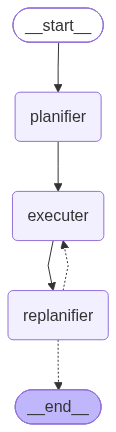

In [10]:
import operator
from typing import Annotated, List, Tuple, TypedDict
from langgraph.graph import StateGraph, START, END

MAX_ETAPES = 10  # garde-fou contre les boucles infinies


class EtatPlanExecute(TypedDict):
    objectif: str
    plan: List[str]
    etapes_passees: Annotated[List[Tuple[str, str]], operator.add]
    reponse: str
    nb_replanifications: int   # adaptations suite à un échec
    nb_affinages: int          # modifications du plan sans imprévu
    etapes_au_dernier_replan: int
    controle_fait: bool


def _liste_etapes(obj):
    etapes = obj.get("etapes") or obj.get("steps") or obj.get("plan")
    if not isinstance(etapes, list):
        raise ValueError("clé 'etapes' absente ou n'est pas une liste")
    etapes = [e if isinstance(e, str) else (e.get("description") or json.dumps(e, ensure_ascii=False))
              for e in etapes if e]
    etapes = [e.strip() for e in etapes if str(e).strip()]
    if not etapes:
        raise ValueError("la liste 'etapes' est vide")
    return etapes


def _historique(etapes_passees):
    if not etapes_passees:
        return "(aucune)"
    return "\n".join(f"{i}. {etape}\n→ {resultat}" for i, (etape, resultat) in enumerate(etapes_passees, 1))


def noeud_planifier(etat: EtatPlanExecute):
    etapes = appeler_llm_json("pe_planificateur", [
        {"role": "system", "content": PROMPT_PLANIFICATEUR},
        {"role": "user", "content": f"OBJECTIF : {etat['objectif']}"},
    ], _liste_etapes)
    afficher("🧭 PLAN INITIAL :", "\n   " + "\n   ".join(f"{i}. {e}" for i, e in enumerate(etapes, 1)), 2000)
    return {"plan": etapes, "nb_replanifications": 0, "nb_affinages": 0, "controle_fait": False, "etapes_au_dernier_replan": 0}


def _valider_action(obj):
    outil = obj.get("outil") or obj.get("tool") or obj.get("action") or "aucun"
    argument = obj.get("argument", obj.get("entree", obj.get("input", obj.get("args", ""))))
    if isinstance(argument, (dict, list)):
        argument = json.dumps(argument, ensure_ascii=False)
    return str(outil), str(argument)


def noeud_executer(etat: EtatPlanExecute):
    etape = etat["plan"][0]
    outil, argument = appeler_llm_json("pe_executeur", [
        {"role": "system", "content": PROMPT_EXECUTEUR},
        {"role": "user", "content": f"OBJECTIF GLOBAL : {etat['objectif']}\n\n"
                                    f"RÉSULTATS DES ÉTAPES PRÉCÉDENTES :\n{_historique(etat['etapes_passees'])}\n\n"
                                    f"ÉTAPE À EXÉCUTER : {etape}"},
    ], _valider_action)
    resultat = executer_outil(outil, argument)
    afficher(f"⚙️  [{len(etat['etapes_passees']) + 1}] {etape}\n   ↳ {outil}({argument})\n   ↳", resultat)
    return {"etapes_passees": [(etape, resultat)], "plan": etat["plan"][1:]}


def _valider_decision(obj):
    action = str(obj.get("action", "")).lower()
    atteint = str(obj.get("objectif_atteint", "")).lower() in ("true", "1", "oui", "yes")
    etapes = obj.get("etapes") or obj.get("steps")
    if action.startswith("contin") and etapes:
        return {"action": "continuer", "etapes": _liste_etapes(obj), "objectif_atteint": atteint}
    if obj.get("reponse"):
        return {"action": "repondre", "reponse": str(obj["reponse"]), "objectif_atteint": atteint}
    if etapes:
        return {"action": "continuer", "etapes": _liste_etapes(obj), "objectif_atteint": atteint}
    raise ValueError("il faut soit action='continuer' avec 'etapes', soit action='repondre' avec 'reponse'")


def noeud_replanifier(etat: EtatPlanExecute):
    forcer = len(etat["etapes_passees"]) >= MAX_ETAPES
    consigne = "\n\nFORCER_REPONSE : limite d'étapes atteinte, réponds maintenant avec action=repondre." if forcer else ""
    messages = [
        {"role": "system", "content": PROMPT_REPLANIFICATEUR},
        {"role": "user", "content": f"OBJECTIF : {etat['objectif']}\n\n"
                                    f"ÉTAPES DÉJÀ EXÉCUTÉES ET RÉSULTATS :\n{_historique(etat['etapes_passees'])}\n\n"
                                    "ÉTAPES RESTANTES DU PLAN :\n"
                                    + ("\n".join(f"- {e}" for e in etat["plan"]) or "(aucune)") + consigne},
    ]
    decision = appeler_llm_json("pe_replanificateur", messages, _valider_decision)
    controle_fait = etat.get("controle_fait", False)

    # Garde-fou : un échec jamais traité (aucune re-planification) ne peut pas clore la tâche sans vérification.
    # Les LLM configurés avec peu de raisonnement ont tendance à « constater » l'échec au lieu de le contourner.
    # échec survenu depuis la dernière re-planification (et donc pas encore pris en compte)
    recents = etat["etapes_passees"][etat.get("etapes_au_dernier_replan", 0):]
    echec_non_traite = any("ÉCHEC" in r or "ERREUR" in r for _, r in recents)
    for _ in range(2):  # au plus 2 contrôles
        if not (decision["action"] == "repondre" and echec_non_traite and not forcer):
            break
        afficher("🛡️ CONTRÔLE : réponse proposée malgré un échec non traité → demande de vérification des alternatives", "")
        controle_fait = True
        messages += [{"role": "assistant", "content": json.dumps(decision, ensure_ascii=False)},
                     {"role": "user", "content": CONTROLE_ECHEC}]
        decision = appeler_llm_json("pe_replanificateur", messages, _valider_decision)

    if decision["action"] == "repondre" or forcer or not decision.get("etapes"):
        reponse = decision.get("reponse") or "Limite d'étapes atteinte. Dernier résultat : " + etat["etapes_passees"][-1][1]
        afficher("✅ RÉPONSE :", reponse, 2000)
        return {"reponse": reponse, "controle_fait": controle_fait}
    nouvelles = decision["etapes"]
    if _normaliser(nouvelles) == _normaliser(etat["plan"]):  # simple reformulation : plan inchangé
        return {"plan": nouvelles, "controle_fait": controle_fait}
    if echec_non_traite:  # adaptation à un imprévu : c'est la re-planification qui nous intéresse
        afficher("🔁 RE-PLANIFICATION (suite à un échec) → nouveau plan restant :", "\n   " + "\n   ".join(nouvelles), 2000)
        return {"plan": nouvelles, "nb_replanifications": etat["nb_replanifications"] + 1, "controle_fait": controle_fait,
                "etapes_au_dernier_replan": len(etat["etapes_passees"])}
    afficher("✏️  Plan affiné (sans imprévu) :", "\n   " + "\n   ".join(nouvelles), 2000)
    return {"plan": nouvelles, "nb_affinages": etat.get("nb_affinages", 0) + 1, "controle_fait": controle_fait}


def _normaliser(etapes):
    return [re.sub(r"[\W_]+", " ", e.lower()).strip() for e in etapes]


def router_apres_replanification(etat: EtatPlanExecute):
    return END if etat.get("reponse") else "executer"


constructeur = StateGraph(EtatPlanExecute)
constructeur.add_node("planifier", noeud_planifier)
constructeur.add_node("executer", noeud_executer)
constructeur.add_node("replanifier", noeud_replanifier)
constructeur.add_edge(START, "planifier")
constructeur.add_edge("planifier", "executer")
constructeur.add_edge("executer", "replanifier")
constructeur.add_conditional_edges("replanifier", router_apres_replanification, ["executer", END])
graphe_plan_execute = constructeur.compile()


def afficher_graphe(graphe):
    """Affiche le graphe en image (service mermaid.ink) ou, à défaut, en texte Mermaid."""
    try:
        from IPython.display import Image, display as _display
        _display(Image(graphe.get_graph().draw_mermaid_png(max_retries=1, retry_delay=0.5)))
    except Exception:
        print(graphe.get_graph().draw_mermaid())


afficher_graphe(graphe_plan_execute)

### 4.3 — Exécution sur le scénario S3 (changement dynamique)

Observez la trace : le plan initial prévoit une réservation Bordeaux + Lyon (l'optimum d'après les données consultées). Au moment de réserver, **Lyon échoue** ; le re-planificateur **modifie le plan** en cours de route.

In [11]:
def executer_plan_execute(tache, graphe=None):
    etat = (graphe or graphe_plan_execute).invoke(
        {"objectif": tache, "plan": [], "etapes_passees": [], "reponse": "", "nb_replanifications": 0,
         "nb_affinages": 0, "controle_fait": False, "etapes_au_dernier_replan": 0},
        config={"recursion_limit": 4 * MAX_ETAPES + 10})
    return etat["reponse"], {"etapes_executees": len(etat["etapes_passees"]),
                             "replanifications": etat.get("nb_replanifications", 0),
                             "affinages": etat.get("nb_affinages", 0)}


VERBOSE = True
demo_pe = mesurer("Plan-and-Execute", executer_plan_execute, "S3")
bilan(demo_pe)

🧭 PLAN INITIAL : 
   1. consulter_stock : P-204
   2. tarifs_transport : Nantes
   3. Analyser les stocks et tarifs pour choisir la répartition entre entrepôts qui minimise le coût tout en respectant un délai ≤3 jours pour 120 unités
   4. reserver_stock : P-204 ; EntrepotA:quantité, EntrepotB:quantité (selon la répartition optimale)
   5. calculatrice : (quantitéA*coûtA)+(quantitéB*coûtB)
⚙️  [1] consulter_stock : P-204
   ↳ consulter_stock(P-204)
   ↳ Stock P-204 (extraction WMS du 22/09/2026 06:00) :
- Bordeaux : 80 unités
- Lille : 60 unités
- Lyon : 150 unités
- Marseille : 200 unités
Total : 490 unités
⚙️  [2] tarifs_transport : Nantes
   ↳ tarifs_transport(Nantes)
   ↳ Transport vers Nantes :
- depuis Bordeaux : 1.60 €/unité, délai 1 jour(s)
- depuis Lille : 2.40 €/unité, délai 3 jour(s)
- depuis Lyon : 2.10 €/unité, délai 2 jour(s)
- depuis Marseille : 1.90 €/unité, délai 4 jour(s)
✏️  Plan affiné (sans imprévu) : 
   reserver_stock : P-204 ; Bordeaux:80, Lyon:40
   calculatric

---
## Étape 5 — Architecture **ReWOO** (*Reasoning WithOut Observation*)

### Principe
ReWOO (Xu et al., 2023) supprime les allers-retours entre le LLM et les observations : le planificateur rédige **en une seule fois** un plan **complet**, dans lequel chaque étape stocke son résultat dans une **variable** (`#E1`, `#E2`…) réutilisable par les étapes suivantes.

```
            ┌──────────────┐   Plan: …  #E1 = consulter_stock[P-204]
  tâche ──▶ │ PLANIFICATEUR │   Plan: …  #E2 = tarifs_transport[Nantes]
            └──────┬───────┘   Plan: …  #E3 = LLM[Stocks : #E1 … Tarifs : #E2 …]
                   ▼           Plan: …  #E4 = reserver_stock[P-204 ; #E3]
            ┌──────────────┐
            │   WORKERS     │  exécutent les étapes et substituent #Ei  (aucun appel LLM,
            └──────┬───────┘  sauf les étapes LLM[…] explicitement prévues)
                   ▼
            ┌──────────────┐
            │   SOLVEUR     │  (1 appel LLM : réponse à partir du plan + preuves)
            └──────────────┘
```

➡️ Coût attendu ≈ `2 + (nombre d'étapes LLM[…])` appels LLM, **quel que soit le nombre d'outils appelés**. En contrepartie, **aucune observation ne peut modifier le plan** : si la réalité diverge des prévisions, ReWOO ne peut pas réagir.

### 5.1 — Les prompts

In [12]:
PROMPT_REWOO_PLANIFICATEUR = f"""Tu es le PLANIFICATEUR d'un système ReWOO. Pour la tâche donnée, rédige À L'AVANCE un plan COMPLET
permettant de la résoudre sans pouvoir observer les résultats intermédiaires.
Chaque étape appelle UN outil ; son résultat est stocké dans une variable #E1, #E2, … que les étapes suivantes
peuvent utiliser dans leur argument.

Outils :
{DESCRIPTION_OUTILS}
- LLM : raisonnement, choix ou calcul à partir de résultats précédents. Argument : une instruction complète qui cite
  les variables nécessaires (#E1, #E2…). Précise le format de réponse attendu si le résultat sert d'argument à un outil.

Format STRICT (une ligne « Plan: » puis une ligne « #Ei = outil[argument] », pour chaque étape) :
Plan: <description de l'étape>
#E1 = nom_outil[argument]

Exemple :
Plan: Connaître le stock du produit P-310.
#E1 = consulter_stock[P-310]
Plan: Connaître les tarifs vers Paris.
#E2 = tarifs_transport[Paris]
Plan: Choisir l'entrepôt le moins cher disposant de 10 unités.
#E3 = LLM[Stocks : #E1. Tarifs : #E2. Quel entrepôt le moins cher dispose de 10 unités ? Réponds uniquement au format Entrepot:10]
Plan: Réserver.
#E4 = reserver_stock[P-310 ; #E3]

Règles : n'utilise pas de crochets à l'intérieur d'un argument ; la calculatrice n'accepte que des nombres (pas de #E) ;
écris chaque #Ei = outil[argument] sur une seule ligne. Commence directement par « Plan: »."""

PROMPT_REWOO_SOLVEUR = """Tu es le SOLVEUR d'un système ReWOO. Résous la tâche à partir du plan exécuté et des preuves
(résultats des outils) ci-dessous. Tu ne peux plus exécuter aucune action.
Utilise les preuves avec prudence : si une étape a échoué (ÉCHEC, ERREUR), dis-le clairement, indique ce qui a réellement
été fait et ce qui reste à faire. Réponds en français, de façon concise, avec les chiffres clés."""

print("✅ Prompts ReWOO définis")

✅ Prompts ReWOO définis


### 5.2 — Le graphe LangGraph

Le **parseur** extrait les triplets `(#Ei, outil, argument)` du plan textuel. Le nœud `worker` exécute une étape à chaque passage, en **substituant** les variables déjà calculées ; une arête conditionnelle boucle sur `worker` jusqu'à épuisement du plan, puis passe au `solveur`.

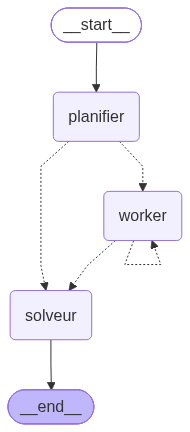

In [13]:
from typing import Dict

MOTIF_ETAPE = re.compile(r"(#E\d+)\s*=\s*([A-Za-z_À-ÿ]+)\s*\[(.*)\]\s*\.?\s*$")
MOTIF_ETAPE_PARENTHESES = re.compile(r"(#E\d+)\s*=\s*([A-Za-z_À-ÿ]+)\s*\((.*)\)\s*\.?\s*$")


def parser_plan_rewoo(texte):
    """Transforme le plan textuel en liste de (description, variable, outil, argument)."""
    etapes, description = [], ""
    for ligne in nettoyer(texte).splitlines():
        l = ligne.replace("**", "").replace("`", "").strip().lstrip("-• ").strip()
        if not l:
            continue
        m = MOTIF_ETAPE.search(l) or MOTIF_ETAPE_PARENTHESES.search(l)
        m_plan = re.match(r"^Plan\s*\d*\s*:\s*(.*)", l, re.I)
        if m_plan:
            description = m_plan.group(1)
            if m:
                description = description[:description.find(m.group(1))].strip()
        if m:
            if m.group(1) in {e[1] for e in etapes}:  # variable déjà définie : étape ignorée
                continue
            argument = m.group(3).strip().strip("'\"")
            etapes.append((description, m.group(1), m.group(2), argument))
            description = ""
    return etapes


def substituer(argument, resultats):
    return re.sub(r"#E\d+", lambda m: resultats.get(m.group(0), m.group(0)), argument)


class EtatReWOO(TypedDict):
    tache: str
    plan_texte: str
    etapes: List[Tuple[str, str, str, str]]
    resultats: Dict[str, str]
    resultat: str


def noeud_planifier_rewoo(etat: EtatReWOO):
    messages = [{"role": "system", "content": PROMPT_REWOO_PLANIFICATEUR},
                {"role": "user", "content": f"TÂCHE : {etat['tache']}"}]
    texte = appeler_llm("rewoo_planificateur", messages)
    etapes = parser_plan_rewoo(texte)
    if not etapes:  # une seule nouvelle tentative guidée
        afficher("   ⚠️ Plan illisible, nouvelle tentative :", texte[:200])
        messages += [{"role": "assistant", "content": texte or "(vide)"},
                     {"role": "user", "content": "Format non respecté. Réécris le plan : lignes « Plan: … » suivies "
                                                 "de lignes « #E1 = outil[argument] »."}]
        texte = appeler_llm("rewoo_planificateur", messages)
        etapes = parser_plan_rewoo(texte)
    afficher("🧭 PLAN ReWOO :", "\n   " + "\n   ".join(f"{v} = {o}[{a}]" for _, v, o, a in etapes), 3000)
    return {"plan_texte": texte, "etapes": etapes, "resultats": {}}


def noeud_worker(etat: EtatReWOO):
    resultats = dict(etat["resultats"])
    _, variable, outil, argument = etat["etapes"][len(resultats)]
    argument_final = substituer(argument, resultats)
    resultat = executer_outil(outil, argument_final, autoriser_llm=True)
    resultats[variable] = resultat
    afficher(f"🔧 {variable} = {outil}[…]\n   ↳", resultat)
    return {"resultats": resultats}


def noeud_solveur(etat: EtatReWOO):
    preuves = ""
    for description, variable, outil, argument in etat["etapes"]:
        preuves += (f"Plan : {description}\n{variable} = {outil}[{substituer(argument, etat['resultats'])}]\n"
                    f"Résultat {variable} : {etat['resultats'].get(variable, '(non exécuté)')}\n\n")
    reponse = appeler_llm("rewoo_solveur", [
        {"role": "system", "content": PROMPT_REWOO_SOLVEUR},
        {"role": "user", "content": f"TÂCHE : {etat['tache']}\n\nPLAN ET PREUVES :\n{preuves}\nRéponse :"},
    ])
    afficher("✅ RÉPONSE :", reponse, 2000)
    return {"resultat": reponse}


def router_worker(etat: EtatReWOO):
    return "solveur" if len(etat["resultats"]) >= len(etat["etapes"]) else "worker"


constructeur = StateGraph(EtatReWOO)
constructeur.add_node("planifier", noeud_planifier_rewoo)
constructeur.add_node("worker", noeud_worker)
constructeur.add_node("solveur", noeud_solveur)
constructeur.add_edge(START, "planifier")
constructeur.add_conditional_edges("planifier", router_worker, ["worker", "solveur"])
constructeur.add_conditional_edges("worker", router_worker, ["worker", "solveur"])
constructeur.add_edge("solveur", END)
graphe_rewoo = constructeur.compile()

afficher_graphe(graphe_rewoo)

### 5.3 — Exécution sur le scénario S3 (changement dynamique)

Même scénario que pour Plan-and-Execute. Comptez les appels LLM… et regardez ce qui se passe quand la réservation à Lyon échoue.

In [14]:
def executer_rewoo(tache, graphe=None):
    etat = (graphe or graphe_rewoo).invoke(
        {"tache": tache, "plan_texte": "", "etapes": [], "resultats": {}, "resultat": ""},
        config={"recursion_limit": 60})
    return etat["resultat"], {"etapes_executees": len(etat["resultats"]), "replanifications": 0, "affinages": 0}


VERBOSE = True
demo_rw = mesurer("ReWOO", executer_rewoo, "S3")
bilan(demo_rw)

🧭 PLAN ReWOO : 
   #E1 = consulter_stock[P-204]
   #E2 = tarifs_transport[Nantes]
   #E3 = LLM[Stocks : #E1. Tarifs : #E2. Besoin : 120 unités à Nantes sous 3 jours maximum. Quelle répartition minimise le coût total ? Réponds uniquement « EntrepotA:quantitéA, EntrepotB:quantitéB ».]
   #E4 = reserver_stock[P-204 ; #E3]
   #E5 = LLM[Répartition : #E3. Tarifs : #E2. Calcule le coût total = Σ (quantité × coût unitaire) pour chaque entrepôt. Donne le résultat numérique avec deux décimales.]
🔧 #E1 = consulter_stock[…]
   ↳ Stock P-204 (extraction WMS du 22/09/2026 06:00) :
- Bordeaux : 80 unités
- Lille : 60 unités
- Lyon : 150 unités
- Marseille : 200 unités
Total : 490 unités
🔧 #E2 = tarifs_transport[…]
   ↳ Transport vers Nantes :
- depuis Bordeaux : 1.60 €/unité, délai 1 jour(s)
- depuis Lille : 2.40 €/unité, délai 3 jour(s)
- depuis Lyon : 2.10 €/unité, délai 2 jour(s)
- depuis Marseille : 1.90 €/unité, délai 4 jour(s)
🔧 #E3 = LLM[…]
   ↳ Bordeaux:80, Lyon:40
🔧 #E4 = reserver_stock[…]


> 🧠 **À retenir** : ReWOO a consommé beaucoup moins d'appels LLM, mais son plan, figé dès le départ, n'a pas pu intégrer l'échec de la réservation. Le solveur peut seulement **constater** le problème, pas le **corriger**.

---
## Étape 6 — Banc de comparaison

On exécute les deux architectures sur les **trois scénarios**, en réinitialisant l'environnement avant chaque exécution. Pour chaque exécution, on relève :

| Mesure | Signification |
|---|---|
| `appels_llm`, `tokens_in`, `tokens_out` | coût (financier et quotas) |
| `duree_s` | durée totale mesurée (LLM + outils) |
| `appels_outils` | nombre d'appels d'outils |
| `replanifications` | adaptations du plan **suite à un échec** (Plan-and-Execute) |
| `affinages` | modifications du plan sans imprévu (précision d'une étape, fusion de deux étapes…) |
| `statut` / `succes` | résultat évalué sur l'état réel de l'environnement |

> `NB_REPETITIONS` permet de répéter chaque mesure (les LLM ne sont pas parfaitement déterministes). Gardez 1 avec un quota gratuit.

In [15]:
NB_REPETITIONS = 1
ARCHITECTURES = {"Plan-and-Execute": executer_plan_execute, "ReWOO": executer_rewoo}
RESULTATS = []


VERBOSE = False
print(f"Mode : {mode_courant()}\n")
for rep in range(1, NB_REPETITIONS + 1):
    for sid in SCENARIOS:
        for nom_archi, fonction in ARCHITECTURES.items():
            ligne = mesurer(nom_archi, fonction, sid, rep)
            RESULTATS.append(ligne)
            print(f"{ligne['scenario']:<28} {nom_archi:<17} {ligne['statut']:<22} appels LLM={ligne['appels_llm']:>2} "
                  f"tokens={ligne['tokens_total']:>6} durée={ligne['duree_s']:>6.1f}s {ligne['erreur'][:80]}")

df = pd.DataFrame(RESULTATS)
colonnes = ["scenario", "architecture", "mode", "statut", "appels_llm", "tokens_in", "tokens_out", "tokens_total",
            "duree_s", "appels_outils", "replanifications", "affinages", "unites", "cout_reel", "cout_optimal"]
display(df[colonnes])

Mode : API groq / openai/gpt-oss-120b

S1 — Devis simple            Plan-and-Execute  ✅ correct              appels LLM= 5 tokens=  4056 durée=  28.9s 
S1 — Devis simple            ReWOO             ✅ correct              appels LLM= 9 tokens=  4924 durée=  37.3s 
S2 — Commande (stable)       Plan-and-Execute  ✅ optimal              appels LLM= 7 tokens=  6224 durée=  32.8s 
S2 — Commande (stable)       ReWOO             ✅ optimal              appels LLM= 6 tokens=  5129 durée=  26.4s 
S3 — Commande (imprévu)      Plan-and-Execute  ✅ optimal              appels LLM= 9 tokens=  8825 durée=  58.9s 
S3 — Commande (imprévu)      ReWOO             ❌ incomplet (80/120)   appels LLM= 5 tokens=  4509 durée=  34.2s 


,scenario,architecture,mode,statut,appels_llm,tokens_in,tokens_out,tokens_total,duree_s,appels_outils,replanifications,affinages,unites,cout_reel,cout_optimal
0,S1 — Devis simple,Plan-and-Execute,API groq / openai/gpt-oss-120b,✅ correct,5,2879,1177,4056,28.87,2,0,1,NaN,NaN,252.0
1,S1 — Devis simple,ReWOO,API groq / openai/gpt-oss-120b,✅ correct,9,2798,2126,4924,37.26,2,0,0,NaN,NaN,252.0
2,S2 — Commande (stable),Plan-and-Execute,API groq / openai/gpt-oss-120b,✅ optimal,7,4632,1592,6224,32.82,3,0,1,120.0,212.0,212.0
3,S2 — Commande (stable),ReWOO,API groq / openai/gpt-oss-120b,✅ optimal,6,2631,2498,5129,26.38,3,0,0,120.0,212.0,212.0
4,S3 — Commande (imprévu),Plan-and-Execute,API groq / openai/gpt-oss-120b,✅ optimal,9,6322,2503,8825,58.85,4,1,1,120.0,224.0,224.0
5,S3 — Commande (imprévu),ReWOO,API groq / openai/gpt-oss-120b,❌ incomplet (80/120),5,2496,2013,4509,34.22,4,0,0,80.0,128.0,224.0


### 6.1 — Visualisation

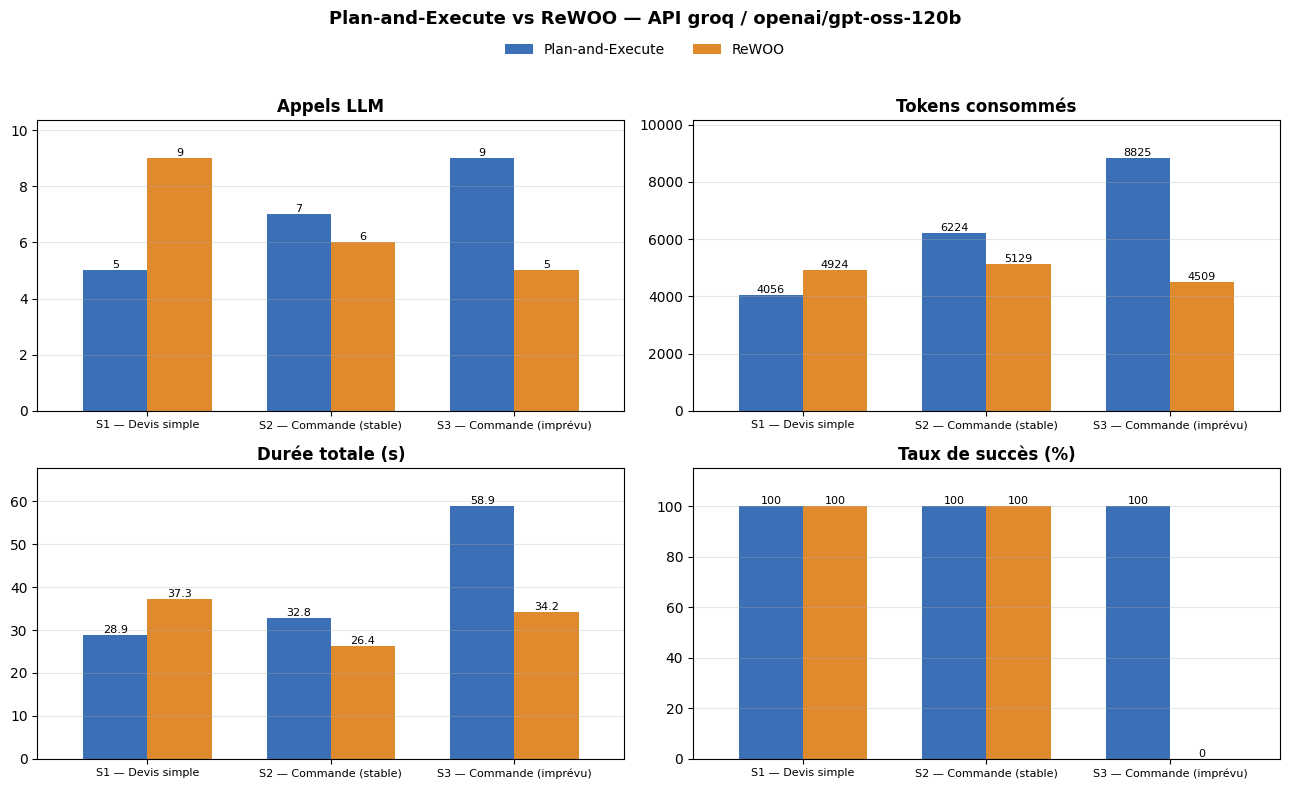

In [16]:
import matplotlib.pyplot as plt

moyennes = df.groupby(["scenario", "architecture"], sort=False)[
    ["appels_llm", "tokens_total", "duree_s", "appels_outils"]].mean().unstack("architecture")
taux_succes = df.groupby(["scenario", "architecture"], sort=False)["succes"].mean().unstack("architecture") * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
couleurs = {"Plan-and-Execute": "#3b6fb6", "ReWOO": "#e08a2e"}
graphiques = [("appels_llm", "Appels LLM"), ("tokens_total", "Tokens consommés"),
              ("duree_s", "Durée totale (s)"), (None, "Taux de succès (%)")]
for ax, (mesure, titre) in zip(axes.flat, graphiques):
    donnees = taux_succes if mesure is None else moyennes[mesure]
    donnees = donnees[[a for a in couleurs if a in donnees.columns]]
    donnees.plot(kind="bar", ax=ax, color=[couleurs[a] for a in donnees.columns], rot=0, width=0.7, legend=False)
    ax.set_title(titre, fontweight="bold")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, max(1, float(donnees.max().max())) * 1.15)
    for conteneur in ax.containers:
        ax.bar_label(conteneur, fmt="%.1f" if mesure == "duree_s" else "%.0f", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
poignees, etiquettes = axes.flat[0].get_legend_handles_labels()
fig.legend(poignees, etiquettes, loc="upper center", ncol=len(etiquettes), bbox_to_anchor=(0.5, 0.955), frameon=False)
mode = " + ".join(df["mode"].unique())
fig.suptitle(f"Plan-and-Execute vs ReWOO — {mode}", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig("comparaison_atelier3.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.2 — Lecture des résultats (questions à traiter dans la synthèse)

1. Sur **S1** et **S2** (environnement prévisible), quel est le ratio d'appels LLM et de tokens entre les deux architectures ? Le résultat est-il de même qualité ?
2. Sur **S3**, pourquoi Plan-and-Execute réussit-il ? Combien d'appels LLM supplémentaires la re-planification a-t-elle coûté ?
3. Pourquoi ReWOO échoue-t-il sur S3 alors que son solveur « voit » l'échec ? Quelle information manquait au planificateur ?
4. Dans Plan-and-Execute, le re-planificateur est appelé **après chaque étape**, même quand tout va bien. Comment réduire ce coût ? *(→ exercice 2)*
5. Quelle part du temps est due au LLM et quelle part aux outils ? Qu'est-ce qui pourrait être parallélisé ? *(→ étape 7)*

In [17]:
print("Détail des appels LLM par rôle :")
for _, ligne in df.iterrows():
    print(f"  {ligne['scenario']:<28} {ligne['architecture']:<17} {ligne['roles']}")
print("\nRéponses finales :")
for _, ligne in df.iterrows():
    print(f"\n▶ {ligne['scenario']} — {ligne['architecture']} ({ligne['statut']})\n  {ligne['reponse'][:500]}")

Détail des appels LLM par rôle :
  S1 — Devis simple            Plan-and-Execute  {'pe_planificateur': 1, 'pe_executeur': 2, 'pe_replanificateur': 2}
  S1 — Devis simple            ReWOO             {'rewoo_planificateur': 1, 'rewoo_worker_llm': 7, 'rewoo_solveur': 1}
  S2 — Commande (stable)       Plan-and-Execute  {'pe_planificateur': 1, 'pe_executeur': 3, 'pe_replanificateur': 3}
  S2 — Commande (stable)       ReWOO             {'rewoo_planificateur': 1, 'rewoo_worker_llm': 4, 'rewoo_solveur': 1}
  S3 — Commande (imprévu)      Plan-and-Execute  {'pe_planificateur': 1, 'pe_executeur': 4, 'pe_replanificateur': 4}
  S3 — Commande (imprévu)      ReWOO             {'rewoo_planificateur': 1, 'rewoo_worker_llm': 3, 'rewoo_solveur': 1}

Réponses finales :

▶ S1 — Devis simple — Plan-and-Execute (✅ correct)
  Le coût de transport pour expédier 120 unités du produit P-204 depuis l'entrepôt de Lyon vers Nantes est de 252 € (2.10 €/unité × 120). Le délai de livraison prévu est de 2 jours.

▶ S1

---
## Étape 7 — Bonus : parallélisation façon **LLMCompiler**

**LLMCompiler** (Kim et al., 2023) pousse l'idée de ReWOO plus loin : le plan est un **graphe de dépendances (DAG)** entre tâches, et toutes les tâches dont les dépendances sont satisfaites s'exécutent **en parallèle**. Un « joiner » décide ensuite de répondre ou de re-planifier.

Nous appliquons ici l'idée clé au plan ReWOO : les dépendances sont déduites des variables `#Ei` citées dans chaque argument, puis l'exécution se fait **par vagues** avec un `ThreadPoolExecutor`. Dans notre scénario, `consulter_stock` et `tarifs_transport` sont indépendants et peuvent s'exécuter simultanément.

In [18]:
from concurrent.futures import ThreadPoolExecutor


def noeud_workers_paralleles(etat: EtatReWOO):
    resultats = dict(etat["resultats"])
    restantes = list(etat["etapes"])
    vague = 0
    while restantes:
        pretes = [e for e in restantes if all(dep in resultats for dep in re.findall(r"#E\d+", e[3]))]
        if not pretes:  # dépendance impossible à satisfaire : on exécute quand même, dans l'ordre
            pretes = restantes[:1]
        vague += 1
        with ThreadPoolExecutor(max_workers=len(pretes)) as pool:
            sorties = list(pool.map(
                lambda e: executer_outil(e[2], substituer(e[3], resultats), autoriser_llm=True), pretes))
        for etape, sortie in zip(pretes, sorties):
            resultats[etape[1]] = sortie
            restantes.remove(etape)
        afficher(f"⚡ Vague {vague} : exécution parallèle de", ", ".join(f"{e[1]}={e[2]}" for e in pretes))
    return {"resultats": resultats}


constructeur = StateGraph(EtatReWOO)
constructeur.add_node("planifier", noeud_planifier_rewoo)
constructeur.add_node("workers_paralleles", noeud_workers_paralleles)
constructeur.add_node("solveur", noeud_solveur)
constructeur.add_edge(START, "planifier")
constructeur.add_edge("planifier", "workers_paralleles")
constructeur.add_edge("workers_paralleles", "solveur")
constructeur.add_edge("solveur", END)
graphe_rewoo_parallele = constructeur.compile()

VERBOSE = True
ligne_par = mesurer("ReWOO parallèle", lambda t: executer_rewoo(t, graphe_rewoo_parallele), "S2")
VERBOSE = False
ligne_seq = mesurer("ReWOO", executer_rewoo, "S2")
RESULTATS_BONUS = [ligne_seq, ligne_par]
print(f"\nS2 — ReWOO séquentiel : {ligne_seq['duree_s']:.2f} s | ReWOO parallèle : {ligne_par['duree_s']:.2f} s "
      f"({ligne_seq['appels_outils']} appels d'outils de {LATENCE_OUTIL}s chacun ; statuts : "
      f"{ligne_seq['statut']} / {ligne_par['statut']})")

🧭 PLAN ReWOO : 
   #E1 = consulter_stock[P-204]
   #E2 = tarifs_transport[Nantes]
   #E3 = LLM[Stocks : #E1. Tarifs et délais : #E2. Besoin : 120 unités à livrer à Nantes en ≤3 jours. Fournis la répartition sous le format Entrepot1:qty1, Entrepot2:qty2, ... en choisissant la combinaison la moins chère.]
   #E4 = LLM[Répartition : #E3. Tarifs : #E2. Calcule le coût total (somme qty_i * coût_i) et répond uniquement avec le nombre, par ex. 432.5]
   #E5 = reserver_stock[P-204 ; #E3]
   #E6 = LLM[Coût total : #E4. Réponds : "Le coût total de transport est #E4 euros.]
⚡ Vague 1 : exécution parallèle de #E1=consulter_stock, #E2=tarifs_transport
⚡ Vague 2 : exécution parallèle de #E3=LLM
⚡ Vague 3 : exécution parallèle de #E4=LLM, #E5=reserver_stock
⚡ Vague 4 : exécution parallèle de #E6=LLM
✅ RÉPONSE : Le coût total de transport est 212.0 euros.

S2 — ReWOO séquentiel : 29.48 s | ReWOO parallèle : 24.24 s (4 appels d'outils de 0.3s chacun ; statuts : ✅ optimal / ✅ optimal)


> Le gain dépend de la **forme du plan** (nombre de tâches indépendantes) et de la **latence des outils**. Avec de vraies API métier (souvent plusieurs centaines de ms), il devient significatif. LLMCompiler ajoute en outre le *streaming* du plan (les tâches démarrent pendant que le planificateur écrit encore) et un « joiner » capable de re-planifier, ce qui combine l'efficacité de ReWOO et l'adaptabilité de Plan-and-Execute.

---
## Étape 8 — Exercices

### Exercice 1 — Changer la nature de l'imprévu
Modifiez `evenements.json` pour que ce soit **Bordeaux** (et non plus Lyon) qui soit bloqué, puis rejouez S3 avec les deux architectures.
*Questions* : quel est le nouvel optimum ? Plan-and-Execute le trouve-t-il ? Que se passe-t-il pour ReWOO ?

In [19]:
# --- Solution de l'exercice 1 ---
evenements_ex1 = [dict(evenements[0], entrepot="Bordeaux", id="WMS-4480",
                       message="inventaire tournant en cours, expéditions suspendues jusqu'au 25/09/2026")]
(DOSSIER / "evenements.json").write_text(json.dumps(evenements_ex1, ensure_ascii=False, indent=2), encoding="utf-8")
env.evenements = evenements_ex1
print(f"Nouvel optimum S3 : {optimum(True):.2f} €")

resultats_ex1 = [mesurer(nom, f, "S3") for nom, f in ARCHITECTURES.items()]
display(pd.DataFrame(resultats_ex1)[["architecture", "statut", "appels_llm", "tokens_total", "unites", "cout_reel", "cout_optimal"]])

# Restauration de l'incident d'origine (Lyon)
(DOSSIER / "evenements.json").write_text(json.dumps(evenements, ensure_ascii=False, indent=2), encoding="utf-8")
env.evenements = evenements
print(f"Incident d'origine restauré → optimum S3 : {optimum(True):.2f} €")

Nouvel optimum S3 : 252.00 €


,architecture,statut,appels_llm,tokens_total,unites,cout_reel,cout_optimal
0,Plan-and-Execute,✅ optimal,9,9443,120,252.0,252.0
1,ReWOO,❌ incomplet (40/120),5,4099,40,84.0,252.0


Incident d'origine restauré → optimum S3 : 224.00 €


### Exercice 2 — Plan-and-Execute « économe »
Le re-planificateur est appelé après **chaque** étape. Modifiez le graphe pour ne l'appeler que si une étape **a échoué** (résultat contenant « ÉCHEC » ou « ERREUR ») ou quand **le plan est terminé**.
*Indice* : ajoutez une arête conditionnelle après le nœud `executer`.

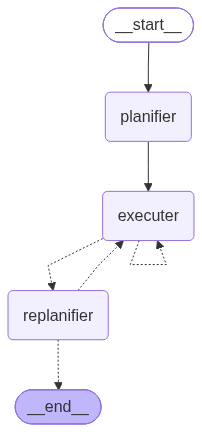

,scenario,architecture,statut,appels_llm,tokens_total,duree_s,replanifications
0,S1 — Devis simple,P&E économe,✅ correct,5,3636,29.46,0
1,S2 — Commande (stable),P&E économe,❌ sur-réservation,10,12802,68.95,1
2,S3 — Commande (imprévu),P&E économe,✅ optimal,9,9307,68.01,1


In [20]:
# --- Solution de l'exercice 2 ---
def router_apres_execution(etat: EtatPlanExecute):
    dernier_resultat = etat["etapes_passees"][-1][1]
    if "ÉCHEC" in dernier_resultat or "ERREUR" in dernier_resultat or not etat["plan"]:
        return "replanifier"
    return "executer"


constructeur = StateGraph(EtatPlanExecute)
constructeur.add_node("planifier", noeud_planifier)
constructeur.add_node("executer", noeud_executer)
constructeur.add_node("replanifier", noeud_replanifier)
constructeur.add_edge(START, "planifier")
constructeur.add_edge("planifier", "executer")
constructeur.add_conditional_edges("executer", router_apres_execution, ["executer", "replanifier"])
constructeur.add_conditional_edges("replanifier", router_apres_replanification, ["executer", END])
graphe_pe_econome = constructeur.compile()
afficher_graphe(graphe_pe_econome)

resultats_ex2 = [mesurer("P&E économe", lambda t: executer_plan_execute(t, graphe_pe_econome), sid) for sid in SCENARIOS]
display(pd.DataFrame(resultats_ex2)[["scenario", "architecture", "statut", "appels_llm", "tokens_total", "duree_s", "replanifications"]])

### Exercice 3 — ReWOO « hybride » avec boucle de re-planification
Ajoutez après le solveur un nœud **vérificateur** (un appel LLM qui répond en JSON `{"objectif_atteint": true/false, "manque": "..."}`). Si l'objectif n'est pas atteint, relancez **un nouveau plan ReWOO** en fournissant au planificateur les résultats déjà obtenus (au maximum 2 re-planifications).
*Questions* : combien d'appels LLM cette variante consomme-t-elle sur S2 et sur S3 par rapport à ReWOO et à Plan-and-Execute ? Ce compromis vous semble-t-il intéressant ?

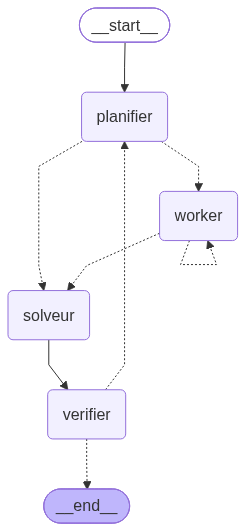

🧭 PLAN ReWOO : 
   #E1 = consulter_stock[P-204]
   #E2 = tarifs_transport[Nantes]
   #E3 = LLM[Stocks : #E1. Tarifs : #E2. Besoin : 120 unités à livrer à Nantes en ≤3 jours. Quelle répartition minimise le coût total tout en respectant les disponibilités ? Réponds uniquement au format « Entrepot1:quantité, Entrepot2:quantité, … ».]
   #E4 = reserver_stock[P-204 ; #E3]
   #E5 = LLM[Tarifs : #E2. Répartition : #E3. Calcule le coût total = Σ (quantité_i * coût_unitaire_i) et donne le résultat numérique uniquement.]
🔧 #E1 = consulter_stock[…]
   ↳ Stock P-204 (extraction WMS du 22/09/2026 06:00) :
- Bordeaux : 80 unités
- Lille : 60 unités
- Lyon : 150 unités
- Marseille : 200 unités
Total : 490 unités
🔧 #E2 = tarifs_transport[…]
   ↳ Transport vers Nantes :
- depuis Bordeaux : 1.60 €/unité, délai 1 jour(s)
- depuis Lille : 2.40 €/unité, délai 3 jour(s)
- depuis Lyon : 2.10 €/unité, délai 2 jour(s)
- depuis Marseille : 1.90 €/unité, délai 4 jour(s)
🔧 #E3 = LLM[…]
   ↳ Bordeaux:80, Lyon:40
🔧

,scenario,architecture,statut,appels_llm,tokens_total,duree_s,replanifications
0,S2 — Commande (stable),ReWOO hybride,✅ optimal,11,9265,60.40,1
1,S3 — Commande (imprévu),ReWOO hybride,✅ optimal,13,14361,94.21,2


In [21]:
# --- Solution de l'exercice 3 ---
PROMPT_VERIFICATEUR = """Tu es le VÉRIFICATEUR d'un système multi-agents. À partir de la tâche et de la réponse du solveur,
indique si la tâche a été ENTIÈREMENT accomplie (toutes les actions demandées ont réussi).
Réponds UNIQUEMENT avec un objet JSON : {"objectif_atteint": true ou false, "manque": "ce qui reste à faire"}"""


class EtatReWOOHybride(EtatReWOO):
    historique: str
    tours: int


def noeud_verifier(etat: EtatReWOOHybride):
    verdict = appeler_llm_json("verificateur", [
        {"role": "system", "content": PROMPT_VERIFICATEUR},
        {"role": "user", "content": f"TÂCHE : {etat['tache']}\n\nRÉPONSE DU SOLVEUR : {etat['resultat']}"},
    ], lambda o: {"ok": str(o.get("objectif_atteint", "")).lower() in ("true", "1", "oui", "yes"),
                  "manque": str(o.get("manque", ""))})
    afficher("🔍 VÉRIFICATION :", verdict)
    if verdict["ok"] or etat["tours"] >= 2:
        return {"tours": etat["tours"] + 1}
    historique = etat["historique"] + f"--- Tentative {etat['tours'] + 1} ---\n" + "\n".join(
        f"{v} = {o}[{a}] → {etat['resultats'].get(v, '')}" for _, v, o, a in etat["etapes"])
    nouvelle_tache = (f"{etat['tache'].split(chr(10) + chr(10) + 'RÉSULTATS DÉJÀ OBTENUS')[0]}\n\n"
                      f"RÉSULTATS DÉJÀ OBTENUS (ne refais pas ce qui a réussi, les réservations réussies sont "
                      f"définitives) :\n{historique}\n\nCE QUI MANQUE : {verdict['manque']}")
    return {"tache": nouvelle_tache, "historique": historique + "\n", "tours": etat["tours"] + 1, "resultat": ""}


def router_verification(etat: EtatReWOOHybride):
    return END if etat["resultat"] else "planifier"


constructeur = StateGraph(EtatReWOOHybride)
constructeur.add_node("planifier", noeud_planifier_rewoo)
constructeur.add_node("worker", noeud_worker)
constructeur.add_node("solveur", noeud_solveur)
constructeur.add_node("verifier", noeud_verifier)
constructeur.add_edge(START, "planifier")
constructeur.add_conditional_edges("planifier", router_worker, ["worker", "solveur"])
constructeur.add_conditional_edges("worker", router_worker, ["worker", "solveur"])
constructeur.add_edge("solveur", "verifier")
constructeur.add_conditional_edges("verifier", router_verification, ["planifier", END])
graphe_rewoo_hybride = constructeur.compile()
afficher_graphe(graphe_rewoo_hybride)


def executer_rewoo_hybride(tache):
    etat = graphe_rewoo_hybride.invoke(
        {"tache": tache, "plan_texte": "", "etapes": [], "resultats": {}, "resultat": "", "historique": "", "tours": 0},
        config={"recursion_limit": 100})
    return etat["resultat"], {"etapes_executees": None, "replanifications": etat["tours"] - 1}


VERBOSE = True
ligne_hybride_s3 = mesurer("ReWOO hybride", executer_rewoo_hybride, "S3")
VERBOSE = False
resultats_ex3 = [mesurer("ReWOO hybride", executer_rewoo_hybride, "S2"), ligne_hybride_s3]
display(pd.DataFrame(resultats_ex3)[["scenario", "architecture", "statut", "appels_llm", "tokens_total", "duree_s", "replanifications"]])

---
## Étape 9 — Synthèse

### 9.1 — Grille de comparaison des frameworks de planification LLM-MA

| Critère | **Plan-and-Execute** | **ReWOO** | **LLMCompiler** |
|---|---|---|---|
| Principe | plan → exécution étape par étape → re-planification après chaque étape | plan complet avec variables `#Ei` → workers → solveur | plan en DAG, exécution parallèle en flux, joiner |
| Appels LLM | élevés : ≈ 1 + 2 × étapes | faibles : 2 + étapes `LLM[…]` | faibles à moyens (1 planif + joiner, + replanifs) |
| Tokens | élevés (historique renvoyé à chaque appel) | faibles (pas d'observations réinjectées dans le planificateur) | faibles à moyens |
| Latence | élevée (séquentiel, LLM à chaque étape) | moyenne (outils séquentiels) | **la plus faible** (parallélisme) |
| Adaptation aux imprévus | ✅ **forte** (re-planification continue) | ❌ nulle (plan figé) | ⚠️ possible via le joiner, par cycles |
| Dépendance à la qualité du plan initial | faible (corrigé en route) | **très forte** | forte |
| Robustesse au format | bonne (JSON court à chaque étape) | fragile (plan long, parsing des `#Ei`) | fragile (DAG + parsing) |
| Cas d'usage types | environnement dynamique, actions à effets de bord, tâches longues et incertaines | tâches prévisibles et répétitives, fort volume, budget ou quotas contraints | nombreuses sous-tâches indépendantes (recherches, appels d'API), latence critique |

### 9.2 — Génération du livrable
La cellule suivante produit `synthese_atelier3.md` : protocole, **résultats mesurés**, analyse chiffrée automatique, grille comparative et une section **« Vos conclusions »** à compléter. Téléchargez-la (ainsi que ce notebook : `Fichier › Télécharger › .ipynb`) pour constituer votre livrable.

In [22]:
from datetime import datetime


def tableau_md(dataframe):
    entetes = list(dataframe.columns)
    lignes = ["| " + " | ".join(map(str, entetes)) + " |", "|" + "---|" * len(entetes)]
    for _, l in dataframe.iterrows():
        lignes.append("| " + " | ".join("" if pd.isna(v) else str(v) for v in l.values) + " |")
    return "\n".join(lignes)


def ratio(a, b):
    return f"{a / b:.1f}×" if b else "n/a"


def valeur(scenario_nom, archi, mesure):
    sel = df[(df["scenario"] == scenario_nom) & (df["architecture"] == archi)]
    return sel[mesure].mean() if len(sel) else float("nan")


noms = {sid: sc["nom"] for sid, sc in SCENARIOS.items()}
analyse = []
for sid in ["S1", "S2", "S3"]:
    n = noms[sid]
    a_pe, a_rw = valeur(n, "Plan-and-Execute", "appels_llm"), valeur(n, "ReWOO", "appels_llm")
    t_pe, t_rw = valeur(n, "Plan-and-Execute", "tokens_total"), valeur(n, "ReWOO", "tokens_total")
    s_pe, s_rw = valeur(n, "Plan-and-Execute", "succes"), valeur(n, "ReWOO", "succes")
    analyse.append(f"- **{n}** : Plan-and-Execute = {a_pe:.0f} appels LLM / {t_pe:.0f} tokens "
                   f"(succès {s_pe * 100:.0f} %) ; ReWOO = {a_rw:.0f} appels / {t_rw:.0f} tokens "
                   f"(succès {s_rw * 100:.0f} %). Plan-and-Execute consomme **{ratio(a_pe, a_rw)}** plus d'appels "
                   f"et **{ratio(t_pe, t_rw)}** plus de tokens.")

extras = []
if "RESULTATS_BONUS" in globals():
    extras += RESULTATS_BONUS
for nom_liste in ["resultats_ex2", "resultats_ex3"]:
    if nom_liste in globals():
        extras += globals()[nom_liste]
df_extras = pd.DataFrame(extras) if extras else pd.DataFrame()

synthese = f"""# Synthèse — Atelier 3 IA102 : Plan-and-Execute vs ReWOO

*Généré le {datetime.now():%d/%m/%Y à %H:%M} — mode : {" + ".join(df["mode"].unique())}
— LangGraph {version("langgraph")}*

## 1. Protocole
- Cas d'usage : système multi-agents logistique (4 entrepôts), outils `consulter_stock`, `tarifs_transport`,
  `reserver_stock`, `calculatrice` (latence simulée de {LATENCE_OUTIL} s par appel).
- Scénarios : S1 devis simple ; S2 commande de 120 unités en environnement stable ; S3 même commande avec un
  **incident survenant pendant l'exécution** (blocage des expéditions à Lyon).
- Évaluation sur l'**état réel** de l'environnement (réservations effectives) comparé à l'optimum calculé.
- Répétitions par mesure : {NB_REPETITIONS}.

## 2. Résultats mesurés
{tableau_md(df[["scenario", "architecture", "statut", "appels_llm", "tokens_total", "duree_s", "appels_outils", "replanifications", "cout_reel", "cout_optimal"]])}

![Comparaison](comparaison_atelier3.png)

## 3. Analyse chiffrée
{chr(10).join(analyse)}

**Variantes (bonus et exercices)**

{tableau_md(df_extras[["scenario", "architecture", "statut", "appels_llm", "tokens_total", "duree_s", "replanifications"]]) if len(df_extras) else "(non exécutées)"}

## 4. Grille comparative

| Critère | Plan-and-Execute | ReWOO | LLMCompiler |
|---|---|---|---|
| Appels LLM | ≈ 1 + 2 × étapes | 2 + étapes LLM[…] | 1 planif + joiner (+ replanifs) |
| Adaptation aux imprévus | forte | nulle | par cycles (joiner) |
| Latence | élevée | moyenne | faible (parallélisme) |
| Point faible | coût et latence | plan figé, dépend des prévisions | complexité, parsing du DAG |
| À privilégier pour | environnements dynamiques, actions à effets de bord | tâches prévisibles, fort volume, budget contraint | nombreuses sous-tâches indépendantes |

## 5. Enseignements clés
1. **ReWOO est nettement plus économe** en appels LLM et en tokens : le planificateur n'est appelé qu'une fois et les
   observations ne sont jamais renvoyées au LLM, sauf dans les étapes `LLM[…]` prévues.
2. **Plan-and-Execute est le seul à réussir quand la réalité diverge du plan** (S3) : la re-planification transforme un
   échec d'action en simple détour, au prix d'appels supplémentaires.
3. Le coût de Plan-and-Execute vient surtout du **re-planificateur appelé à chaque étape** ; ne l'appeler qu'en cas
   d'échec (exercice 2) réduit fortement ce surcoût tout en conservant l'adaptabilité.
4. Un **ReWOO hybride** (vérificateur + re-planification sur échec, exercice 3) combine sobriété nominale et capacité
   de rattrapage : c'est l'idée reprise par le *joiner* de LLMCompiler.
5. L'évaluation d'un agent doit porter sur **ses actions réelles**, pas seulement sur son discours.

## 6. Vos conclusions (à compléter)
- **Q1 — Environnement prévisible (S1, S2)** : …
- **Q2 — Changement dynamique (S3)** : …
- **Q3 — Pourquoi ReWOO échoue-t-il sur S3 ?** : …
- **Q4 — Optimisation de Plan-and-Execute** : …
- **Q5 — Recommandation pour votre organisation** (quelle architecture, pour quel processus, avec quels garde-fous ?) : …
"""

Path("synthese_atelier3.md").write_text(synthese, encoding="utf-8")
print(synthese)
print("💾 Fichiers produits : synthese_atelier3.md, comparaison_atelier3.png")

# Synthèse — Atelier 3 IA102 : Plan-and-Execute vs ReWOO

*Généré le 22/09/2026 à 22:16 — mode : API groq / openai/gpt-oss-120b
— LangGraph 1.2.11*

## 1. Protocole
- Cas d'usage : système multi-agents logistique (4 entrepôts), outils `consulter_stock`, `tarifs_transport`,
  `reserver_stock`, `calculatrice` (latence simulée de 0.3 s par appel).
- Scénarios : S1 devis simple ; S2 commande de 120 unités en environnement stable ; S3 même commande avec un
  **incident survenant pendant l'exécution** (blocage des expéditions à Lyon).
- Évaluation sur l'**état réel** de l'environnement (réservations effectives) comparé à l'optimum calculé.
- Répétitions par mesure : 1.

## 2. Résultats mesurés
| scenario | architecture | statut | appels_llm | tokens_total | duree_s | appels_outils | replanifications | cout_reel | cout_optimal |
|---|---|---|---|---|---|---|---|---|---|
| S1 — Devis simple | Plan-and-Execute | ✅ correct | 5 | 4056 | 28.87 | 2 | 0 |  | 252.0 |
| S1 — Devis simple | ReWOO | ✅ c

In [23]:
# Téléchargement des livrables (Colab uniquement ; sans effet ailleurs)
try:
    from google.colab import files
    files.download("synthese_atelier3.md")
    files.download("comparaison_atelier3.png")
except Exception:
    print("Hors Colab : les fichiers sont disponibles dans le répertoire courant.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Pour aller plus loin
- Xu et al., *ReWOO: Decoupling Reasoning from Observations for Efficient Augmented Language Models*, 2023 — arXiv:2305.18323
- Wang et al., *Plan-and-Solve Prompting*, 2023 — arXiv:2305.04091
- Kim et al., *An LLM Compiler for Parallel Function Calling*, 2023 — arXiv:2312.04120
- Documentation LangGraph : https://docs.langchain.com/oss/python/langgraph/overview

**Pistes d'extension** : mémoriser les plans réussis pour les réutiliser (mémoire long terme, cf. chapitre 1) ; ajouter une validation humaine avant `reserver_stock` (*Human-in-the-Loop* avec `interrupt`) ; confier chaque rôle à un modèle différent (grand modèle pour planifier, petit modèle pour exécuter) et mesurer l'effet sur le coût.